In [1]:
# ============================================================
# PROJECT 2 — LINEAR REGRESSION
# AI ADOPTION AND SUBSEQUENT REVENUE OUTCOMES
# ============================================================

# ============================================================
# STEP 1 — IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [9]:
import pandas as pd
import numpy as np

# ============================================================
# STEP 2 — LOAD THE ORIGINAL EXCEL DATA
# ============================================================

file_path = r"C:\Users\McCaiT01\OneDrive - CPGPLC\Misc\Code\DTSC Studio 2\Sector by Employment Size Class.xlsx"

df = pd.read_excel(file_path)

print("Original dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Original dataset shape: (11622, 85)

Columns:
['Sector', 'Empsize', 'Question ID', 'Question', 'Answer ID', 'Answer', '202619', '202618', '202617', '202616', '202615', '202614', '202613', '202612', '202611', '202610', '202609', '202608', '202607', '202606', '202605', '202604', '202603', '202602', '202601', '202526', '202525', '202524', '202523', '202522', '202521', '202520', '202519', '202518', '202517', '202516', '202515', '202514', '202513', '202512', '202511', '202510', '202509', '202508', '202507', '202506', '202505', '202504', '202503', '202502', '202501', '202426', '202425', '202424', '202423', '202422', '202421', '202420', '202419', '202418', '202417', '202416', '202415', '202414', '202413', '202412', '202411', '202410', '202409', '202408', '202407', '202406', '202405', '202404', '202403', '202402', '202401', '202326', '202325', '202324', '202323', '202322', '202321', '202320', '202319']

First 5 rows:


,Sector,Empsize,Question ID,Question,Answer ID,Answer,202619,202618,202617,202616,...,202402,202401,202326,202325,202324,202323,202322,202321,202320,202319
0,11,A,3.0,"Overall, how would you describe this business'...",1.0,Excellent,9.3%,S,S,S,...,10.2%,10.8%,12.4%,12.9%,18.9%,7.5%,9.2%,15.5%,9.3%,14.8%
1,11,A,3.0,"Overall, how would you describe this business'...",2.0,Above average,27.1%,S,15.2%,22.2%,...,10.5%,15.4%,15.2%,18.3%,10.7%,22.9%,21.2%,15.1%,18.3%,18.3%
2,11,A,3.0,"Overall, how would you describe this business'...",3.0,Average,48.7%,62.0%,45.7%,52.7%,...,55.7%,53.8%,53.0%,46.5%,51.6%,44.5%,41.6%,42.4%,57.6%,46.4%
3,11,A,3.0,"Overall, how would you describe this business'...",4.0,Below average,S,17.4%,32.4%,13.3%,...,18.2%,14.9%,6.2%,13.1%,8.8%,18.6%,14.7%,13.2%,9.1%,18.6%
4,11,A,3.0,"Overall, how would you describe this business'...",5.0,Poor,S,S,S,S,...,5.4%,S,13.2%,S,10.0%,6.6%,13.4%,13.7%,5.6%,S


In [10]:
# ============================================================
# STEP 3 — CHECK THE RAW DATA STRUCTURE
# ============================================================

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nQuestion IDs:")
print(df["Question ID"].dropna().unique())

print("\nAnswers:")
print(df["Answer"].dropna().unique())

Dataset shape: (11622, 85)

Columns:
['Sector', 'Empsize', 'Question ID', 'Question', 'Answer ID', 'Answer', '202619', '202618', '202617', '202616', '202615', '202614', '202613', '202612', '202611', '202610', '202609', '202608', '202607', '202606', '202605', '202604', '202603', '202602', '202601', '202526', '202525', '202524', '202523', '202522', '202521', '202520', '202519', '202518', '202517', '202516', '202515', '202514', '202513', '202512', '202511', '202510', '202509', '202508', '202507', '202506', '202505', '202504', '202503', '202502', '202501', '202426', '202425', '202424', '202423', '202422', '202421', '202420', '202419', '202418', '202417', '202416', '202415', '202414', '202413', '202412', '202411', '202410', '202409', '202408', '202407', '202406', '202405', '202404', '202403', '202402', '202401', '202326', '202325', '202324', '202323', '202322', '202321', '202320', '202319']

Question IDs:
[ 3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18. 19. 20.
 21. 22. 23. 

In [11]:
# ============================================================
# STEP 4 — EXTRACT REVENUE AND AI DATA
# ============================================================

# Revenue question = Question 4
# AI question = Question 7

revenue = df[df["Question ID"] == 4.0].copy()

ai = df[df["Question ID"] == 7.0].copy()

print("Revenue rows:", len(revenue))
print("AI rows:", len(ai))

print("\nRevenue answers:")
print(revenue["Answer"].dropna().unique())

print("\nAI answers:")
print(ai["Answer"].dropna().unique())

Revenue rows: 420
AI rows: 420

Revenue answers:
<StringArray>
['Increased', 'Decreased', 'No change']
Length: 3, dtype: str

AI answers:
<StringArray>
['Yes', 'No', 'Do not know']
Length: 3, dtype: str


In [12]:
# ============================================================
# STEP 5 — IDENTIFY SURVEY PERIOD COLUMNS
# ============================================================

id_columns = [
    "Sector",
    "Empsize",
    "Question ID",
    "Question",
    "Answer"
]

period_columns = [
    col for col in df.columns
    if str(col).isdigit()
]

print("Number of survey periods:", len(period_columns))

print("\nFirst periods:")
print(period_columns[:10])

print("\nLast periods:")
print(period_columns[-10:])

Number of survey periods: 79

First periods:
['202619', '202618', '202617', '202616', '202615', '202614', '202613', '202612', '202611', '202610']

Last periods:
['202402', '202401', '202326', '202325', '202324', '202323', '202322', '202321', '202320', '202319']


In [13]:
# ============================================================
# STEP 5 — IDENTIFY SURVEY PERIOD COLUMNS
# ============================================================

id_columns = [
    "Sector",
    "Empsize",
    "Question ID",
    "Question",
    "Answer"
]

period_columns = [
    col for col in df.columns
    if str(col).isdigit()
]

print("Number of survey periods:", len(period_columns))

print("\nFirst periods:")
print(period_columns[:10])

print("\nLast periods:")
print(period_columns[-10:])

Number of survey periods: 79

First periods:
['202619', '202618', '202617', '202616', '202615', '202614', '202613', '202612', '202611', '202610']

Last periods:
['202402', '202401', '202326', '202325', '202324', '202323', '202322', '202321', '202320', '202319']


In [14]:
# ============================================================
# STEP 7 — CREATE REVENUE PERCENTAGE DATA
# ============================================================

revenue_wide = (
    revenue
    .pivot_table(
        index=["Sector", "Empsize"],
        columns="Answer",
        values=period_columns,
        aggfunc="first"
    )
)

print("Revenue wide shape:", revenue_wide.shape)

Revenue wide shape: (140, 237)


In [15]:
# ============================================================
# STEP 7 — CREATE REVENUE PERCENTAGE DATA
# ============================================================

revenue_wide = (
    revenue
    .pivot_table(
        index=["Sector", "Empsize"],
        columns="Answer",
        values=period_columns,
        aggfunc="first"
    )
)

print("Revenue wide shape:", revenue_wide.shape)

Revenue wide shape: (140, 237)


In [16]:
# ============================================================
# STEP 9 — CREATE AI ADOPTION DATA
# ============================================================

ai_yes = ai[ai["Answer"] == "Yes"].copy()

ai_yes = ai_yes[
    ["Sector", "Empsize"] + period_columns
].copy()

ai_yes = ai_yes.rename(
    columns={
        period: f"{period}_AI_Yes_Percentage"
        for period in period_columns
    }
)

print("AI adoption dataset shape:", ai_yes.shape)

display(ai_yes.head())

AI adoption dataset shape: (140, 81)


,Sector,Empsize,202619_AI_Yes_Percentage,202618_AI_Yes_Percentage,202617_AI_Yes_Percentage,202616_AI_Yes_Percentage,202615_AI_Yes_Percentage,202614_AI_Yes_Percentage,202613_AI_Yes_Percentage,202612_AI_Yes_Percentage,...,202402_AI_Yes_Percentage,202401_AI_Yes_Percentage,202326_AI_Yes_Percentage,202325_AI_Yes_Percentage,202324_AI_Yes_Percentage,202323_AI_Yes_Percentage,202322_AI_Yes_Percentage,202321_AI_Yes_Percentage,202320_AI_Yes_Percentage,202319_AI_Yes_Percentage
14,11,A,S,S,S,14.8%,S,S,S,S,...,.,.,.,.,.,.,.,.,.,.
97,11,B,S,S,S,S,S,S,S,S,...,.,.,.,.,.,.,.,.,.,.
180,11,C,S,S,S,S,S,S,S,S,...,.,.,.,.,.,.,.,.,.,.
263,11,D,S,S,S,S,S,S,S,S,...,.,.,.,.,.,.,.,.,.,.
346,11,E,S,S,S,S,S,S,S,S,...,.,.,.,.,.,.,.,.,.,.


In [17]:
# ============================================================
# STEP 9 — CREATE AI ADOPTION DATA
# ============================================================

ai_yes = ai[ai["Answer"] == "Yes"].copy()

ai_yes = ai_yes[
    ["Sector", "Empsize"] + period_columns
].copy()

ai_yes = ai_yes.rename(
    columns={
        period: f"{period}_AI_Yes_Percentage"
        for period in period_columns
    }
)

print("AI adoption dataset shape:", ai_yes.shape)

display(ai_yes.head())

AI adoption dataset shape: (140, 81)


,Sector,Empsize,202619_AI_Yes_Percentage,202618_AI_Yes_Percentage,202617_AI_Yes_Percentage,202616_AI_Yes_Percentage,202615_AI_Yes_Percentage,202614_AI_Yes_Percentage,202613_AI_Yes_Percentage,202612_AI_Yes_Percentage,...,202402_AI_Yes_Percentage,202401_AI_Yes_Percentage,202326_AI_Yes_Percentage,202325_AI_Yes_Percentage,202324_AI_Yes_Percentage,202323_AI_Yes_Percentage,202322_AI_Yes_Percentage,202321_AI_Yes_Percentage,202320_AI_Yes_Percentage,202319_AI_Yes_Percentage
14,11,A,S,S,S,14.8%,S,S,S,S,...,.,.,.,.,.,.,.,.,.,.
97,11,B,S,S,S,S,S,S,S,S,...,.,.,.,.,.,.,.,.,.,.
180,11,C,S,S,S,S,S,S,S,S,...,.,.,.,.,.,.,.,.,.,.
263,11,D,S,S,S,S,S,S,S,S,...,.,.,.,.,.,.,.,.,.,.
346,11,E,S,S,S,S,S,S,S,S,...,.,.,.,.,.,.,.,.,.,.


In [24]:
# ============================================================
# STEPS 10–13 — REBUILD REVENUE PERCENTAGE DATA
# ============================================================

# ------------------------------------------------------------
# STEP 10 — Inspect the original revenue dataframe
# ------------------------------------------------------------

print("Revenue dataframe shape:", revenue.shape)
print("\nRevenue columns:")
print(revenue.columns.tolist()[:30])

print("\nFirst few rows:")
display(revenue.head())


# ------------------------------------------------------------
# STEP 11 — IDENTIFY REVENUE PERCENTAGE COLUMNS
# ------------------------------------------------------------

# Find columns that contain the three revenue categories.
revenue_increased_cols = [
    col for col in revenue.columns
    if "Increased" in str(col)
]

revenue_decreased_cols = [
    col for col in revenue.columns
    if "Decreased" in str(col)
]

revenue_no_change_cols = [
    col for col in revenue.columns
    if "No change" in str(col) or "No Change" in str(col)
]

print("\nRevenue Increased columns:")
print(revenue_increased_cols[:10])

print("\nRevenue Decreased columns:")
print(revenue_decreased_cols[:10])

print("\nRevenue No Change columns:")
print(revenue_no_change_cols[:10])


# ------------------------------------------------------------
# STEP 12 — CONVERT REVENUE DATA FROM WIDE TO LONG FORMAT
# ------------------------------------------------------------

# We expect columns to look something like:
#
# 202619_Increased
# 202619_Decreased
# 202619_No change
#
# or similar.
#
# Instead of assuming the exact names, we extract the
# period and category from the column names.

revenue_records = []

for col in revenue.columns:

    col_str = str(col)

    # Skip identifier columns
    if col_str in ["Sector", "Empsize"]:
        continue

    # Determine revenue category
    if "Increased" in col_str:
        category = "Increased"

    elif "Decreased" in col_str:
        category = "Decreased"

    elif "No change" in col_str or "No Change" in col_str:
        category = "No change"

    else:
        continue

    # Extract the period from the beginning of the column name
    period = col_str.split("_")[0]

    # Keep only columns whose first component looks like a period
    if not period.isdigit():
        continue

    temp = revenue[
        ["Sector", "Empsize", col]
    ].copy()

    temp["Period"] = period
    temp["Revenue_Category"] = category

    temp = temp.rename(columns={col: "Percentage"})

    revenue_records.append(temp)


# Combine everything
if len(revenue_records) == 0:
    raise ValueError(
        "No revenue percentage columns were found. "
        "Print revenue.columns.tolist() and inspect the actual column names."
    )

revenue_long = pd.concat(
    revenue_records,
    ignore_index=True
)

print("\nRevenue long-format shape:", revenue_long.shape)

print("\nRevenue categories:")
print(revenue_long["Revenue_Category"].value_counts())

print("\nFirst 10 observations:")
display(revenue_long.head(10))


# ------------------------------------------------------------
# STEP 13 — PIVOT INTO ONE ROW PER
# SECTOR / EMPLOYMENT SIZE / PERIOD
# ------------------------------------------------------------

revenue_pct = (
    revenue_long
    .pivot_table(
        index=["Sector", "Empsize", "Period"],
        columns="Revenue_Category",
        values="Percentage",
        aggfunc="first"
    )
    .reset_index()
)

# Remove the pivot column name
revenue_pct.columns.name = None


# Rename columns
revenue_pct = revenue_pct.rename(
    columns={
        "Increased": "Revenue_Increased_Percentage",
        "Decreased": "Revenue_Decreased_Percentage",
        "No change": "Revenue_No_Change_Percentage"
    }
)

# Make sure all expected columns exist
expected_revenue_cols = [
    "Revenue_Increased_Percentage",
    "Revenue_Decreased_Percentage",
    "Revenue_No_Change_Percentage"
]

for col in expected_revenue_cols:
    if col not in revenue_pct.columns:
        revenue_pct[col] = np.nan


# Convert percentages to numeric
for col in expected_revenue_cols:

    revenue_pct[col] = (
        revenue_pct[col]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.strip()
        .replace({
            "S": np.nan,
            ".": np.nan,
            "": np.nan,
            "nan": np.nan
        })
    )

    revenue_pct[col] = pd.to_numeric(
        revenue_pct[col],
        errors="coerce"
    )


print("\nRevenue percentage dataset shape:", revenue_pct.shape)

print("\nColumns:")
print(revenue_pct.columns.tolist())

print("\nMissing values:")
print(revenue_pct[expected_revenue_cols].isna().sum())

print("\nFirst 10 observations:")
display(revenue_pct.head(10))

Revenue dataframe shape: (420, 85)

Revenue columns:
['Sector', 'Empsize', 'Question ID', 'Question', 'Answer ID', 'Answer', '202619', '202618', '202617', '202616', '202615', '202614', '202613', '202612', '202611', '202610', '202609', '202608', '202607', '202606', '202605', '202604', '202603', '202602', '202601', '202526', '202525', '202524', '202523', '202522']

First few rows:


,Sector,Empsize,Question ID,Question,Answer ID,Answer,202619,202618,202617,202616,...,202402,202401,202326,202325,202324,202323,202322,202321,202320,202319
5,11,A,4.0,"In the last two weeks, how did this business's...",1.0,Increased,16.5%,S,S,12.5%,...,S,S,12.4%,9.6%,4.9%,S,5.3%,13.8%,16.4%,S
6,11,A,4.0,"In the last two weeks, how did this business's...",2.0,Decreased,29.0%,34.3%,24.3%,18.7%,...,17.7%,40.0%,34.4%,37.2%,24.4%,35.9%,35.2%,29.5%,30.2%,28.1%
7,11,A,4.0,"In the last two weeks, how did this business's...",3.0,No change,54.5%,62.0%,65.5%,68.8%,...,77.9%,54.3%,53.2%,53.2%,70.7%,55.3%,59.5%,56.7%,53.4%,68.1%
88,11,B,4.0,"In the last two weeks, how did this business's...",1.0,Increased,S,S,S,S,...,S,S,S,S,S,S,S,S,S,12.5%
89,11,B,4.0,"In the last two weeks, how did this business's...",2.0,Decreased,39.7%,S,S,46.1%,...,S,17.2%,48.9%,28.2%,20.9%,36.5%,S,31.1%,33.0%,39.0%



Revenue Increased columns:
[]

Revenue Decreased columns:
[]

Revenue No Change columns:
[]


ValueError: No revenue percentage columns were found. Print revenue.columns.tolist() and inspect the actual column names.

In [25]:
# ============================================================
# REVENUE DATA DIAGNOSTIC
# ============================================================

print("Revenue shape:", revenue.shape)

print("\nALL REVENUE COLUMNS:")
for i, col in enumerate(revenue.columns):
    print(i, repr(col))

print("\nFIRST 5 ROWS:")
display(revenue.head())

Revenue shape: (420, 85)

ALL REVENUE COLUMNS:
0 'Sector'
1 'Empsize'
2 'Question ID'
3 'Question'
4 'Answer ID'
5 'Answer'
6 '202619'
7 '202618'
8 '202617'
9 '202616'
10 '202615'
11 '202614'
12 '202613'
13 '202612'
14 '202611'
15 '202610'
16 '202609'
17 '202608'
18 '202607'
19 '202606'
20 '202605'
21 '202604'
22 '202603'
23 '202602'
24 '202601'
25 '202526'
26 '202525'
27 '202524'
28 '202523'
29 '202522'
30 '202521'
31 '202520'
32 '202519'
33 '202518'
34 '202517'
35 '202516'
36 '202515'
37 '202514'
38 '202513'
39 '202512'
40 '202511'
41 '202510'
42 '202509'
43 '202508'
44 '202507'
45 '202506'
46 '202505'
47 '202504'
48 '202503'
49 '202502'
50 '202501'
51 '202426'
52 '202425'
53 '202424'
54 '202423'
55 '202422'
56 '202421'
57 '202420'
58 '202419'
59 '202418'
60 '202417'
61 '202416'
62 '202415'
63 '202414'
64 '202413'
65 '202412'
66 '202411'
67 '202410'
68 '202409'
69 '202408'
70 '202407'
71 '202406'
72 '202405'
73 '202404'
74 '202403'
75 '202402'
76 '202401'
77 '202326'
78 '202325'
79 '

,Sector,Empsize,Question ID,Question,Answer ID,Answer,202619,202618,202617,202616,...,202402,202401,202326,202325,202324,202323,202322,202321,202320,202319
5,11,A,4.0,"In the last two weeks, how did this business's...",1.0,Increased,16.5%,S,S,12.5%,...,S,S,12.4%,9.6%,4.9%,S,5.3%,13.8%,16.4%,S
6,11,A,4.0,"In the last two weeks, how did this business's...",2.0,Decreased,29.0%,34.3%,24.3%,18.7%,...,17.7%,40.0%,34.4%,37.2%,24.4%,35.9%,35.2%,29.5%,30.2%,28.1%
7,11,A,4.0,"In the last two weeks, how did this business's...",3.0,No change,54.5%,62.0%,65.5%,68.8%,...,77.9%,54.3%,53.2%,53.2%,70.7%,55.3%,59.5%,56.7%,53.4%,68.1%
88,11,B,4.0,"In the last two weeks, how did this business's...",1.0,Increased,S,S,S,S,...,S,S,S,S,S,S,S,S,S,12.5%
89,11,B,4.0,"In the last two weeks, how did this business's...",2.0,Decreased,39.7%,S,S,46.1%,...,S,17.2%,48.9%,28.2%,20.9%,36.5%,S,31.1%,33.0%,39.0%


In [26]:
# ============================================================
# STEPS 10–13 — PREPARE REVENUE PERCENTAGES
# ============================================================

# ------------------------------------------------------------
# STEP 10 — IDENTIFY REVENUE ANSWER CATEGORIES
# ------------------------------------------------------------

print("Unique revenue answers:")

print(
    revenue["Answer"]
    .dropna()
    .astype(str)
    .unique()
)


# ------------------------------------------------------------
# STEP 11 — KEEP THE REVENUE ANSWER CATEGORIES
# ------------------------------------------------------------

# Clean the Answer column
revenue["Answer_Clean"] = (
    revenue["Answer"]
    .astype(str)
    .str.strip()
)

print("\nRevenue answer distribution:")

print(
    revenue["Answer_Clean"]
    .value_counts(dropna=False)
)


# ------------------------------------------------------------
# STEP 12 — CONVERT REVENUE DATA TO LONG FORMAT
# ------------------------------------------------------------

# These are the period columns.
# A period is a numeric column name such as 202619.

period_cols = [
    col for col in revenue.columns
    if str(col).isdigit()
]

print("\nNumber of period columns:", len(period_cols))
print("First periods:", period_cols[:10])
print("Last periods:", period_cols[-10:])


# Melt the revenue dataset.
#
# Each row will become:
# Sector | Empsize | Answer | Period | Percentage

revenue_long = revenue.melt(
    id_vars=[
        "Sector",
        "Empsize",
        "Question ID",
        "Question",
        "Answer ID",
        "Answer",
        "Answer_Clean"
    ],
    value_vars=period_cols,
    var_name="Period",
    value_name="Percentage"
)

print("\nRevenue long-format shape:")
print(revenue_long.shape)

print("\nFirst 10 observations:")
display(revenue_long.head(10))


# ------------------------------------------------------------
# STEP 13 — IDENTIFY THE THREE REVENUE CATEGORIES
# ------------------------------------------------------------

# First, inspect the actual answer labels.
print("\nUnique Answer_Clean values:")
print(
    sorted(
        revenue_long["Answer_Clean"]
        .dropna()
        .unique()
    )
)

Unique revenue answers:
<StringArray>
['Increased', 'Decreased', 'No change']
Length: 3, dtype: str

Revenue answer distribution:
Answer_Clean
Increased    140
Decreased    140
No change    140
Name: count, dtype: int64

Number of period columns: 79
First periods: ['202619', '202618', '202617', '202616', '202615', '202614', '202613', '202612', '202611', '202610']
Last periods: ['202402', '202401', '202326', '202325', '202324', '202323', '202322', '202321', '202320', '202319']

Revenue long-format shape:
(33180, 9)

First 10 observations:


,Sector,Empsize,Question ID,Question,Answer ID,Answer,Answer_Clean,Period,Percentage
0,11,A,4.0,"In the last two weeks, how did this business's...",1.0,Increased,Increased,202619,16.5%
1,11,A,4.0,"In the last two weeks, how did this business's...",2.0,Decreased,Decreased,202619,29.0%
2,11,A,4.0,"In the last two weeks, how did this business's...",3.0,No change,No change,202619,54.5%
3,11,B,4.0,"In the last two weeks, how did this business's...",1.0,Increased,Increased,202619,S
4,11,B,4.0,"In the last two weeks, how did this business's...",2.0,Decreased,Decreased,202619,39.7%
5,11,B,4.0,"In the last two weeks, how did this business's...",3.0,No change,No change,202619,51.6%
6,11,C,4.0,"In the last two weeks, how did this business's...",1.0,Increased,Increased,202619,S
7,11,C,4.0,"In the last two weeks, how did this business's...",2.0,Decreased,Decreased,202619,S
8,11,C,4.0,"In the last two weeks, how did this business's...",3.0,No change,No change,202619,86.6%
9,11,D,4.0,"In the last two weeks, how did this business's...",1.0,Increased,Increased,202619,S



Unique Answer_Clean values:
['Decreased', 'Increased', 'No change']


In [27]:
# ============================================================
# STEP 14 — CREATE REVENUE PERCENTAGE DATASET
# ============================================================

# Convert percentage strings to numeric values
revenue_long["Percentage"] = (
    revenue_long["Percentage"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.strip()
    .replace({
        "S": np.nan,
        ".": np.nan,
        "": np.nan,
        "nan": np.nan
    })
)

revenue_long["Percentage"] = pd.to_numeric(
    revenue_long["Percentage"],
    errors="coerce"
)

# Create one row per Sector / Empsize / Period
revenue_pct = (
    revenue_long
    .pivot_table(
        index=["Sector", "Empsize", "Period"],
        columns="Answer_Clean",
        values="Percentage",
        aggfunc="first"
    )
    .reset_index()
)

revenue_pct.columns.name = None

# Rename columns
revenue_pct = revenue_pct.rename(
    columns={
        "Increased": "Revenue_Increased_Percentage",
        "Decreased": "Revenue_Decreased_Percentage",
        "No change": "Revenue_No_Change_Percentage"
    }
)

print("Revenue percentage dataset shape:")
print(revenue_pct.shape)

print("\nColumns:")
print(revenue_pct.columns.tolist())

print("\nMissing values:")
print(
    revenue_pct[
        [
            "Revenue_Increased_Percentage",
            "Revenue_Decreased_Percentage",
            "Revenue_No_Change_Percentage"
        ]
    ].isna().sum()
)

print("\nFirst 10 observations:")
display(revenue_pct.head(10))

Revenue percentage dataset shape:
(9449, 6)

Columns:
['Sector', 'Empsize', 'Period', 'Revenue_Decreased_Percentage', 'Revenue_Increased_Percentage', 'Revenue_No_Change_Percentage']

Missing values:
Revenue_Increased_Percentage    1802
Revenue_Decreased_Percentage    1788
Revenue_No_Change_Percentage     146
dtype: int64

First 10 observations:


,Sector,Empsize,Period,Revenue_Decreased_Percentage,Revenue_Increased_Percentage,Revenue_No_Change_Percentage
0,11,A,202319,28.1,NaN,68.1
1,11,A,202320,30.2,16.4,53.4
2,11,A,202321,29.5,13.8,56.7
3,11,A,202322,35.2,5.3,59.5
4,11,A,202323,35.9,NaN,55.3
5,11,A,202324,24.4,4.9,70.7
6,11,A,202325,37.2,9.6,53.2
7,11,A,202326,34.4,12.4,53.2
8,11,A,202401,40.0,NaN,54.3
9,11,A,202402,17.7,NaN,77.9


In [28]:
# ============================================================
# STEP 15 — CREATE CONTINUOUS REVENUE CHANGE TARGET
# ============================================================

revenue_pct["Revenue_Change_Score"] = (
    revenue_pct["Revenue_Increased_Percentage"]
    - revenue_pct["Revenue_Decreased_Percentage"]
)

print("Revenue Change Score summary:")
print(
    revenue_pct["Revenue_Change_Score"].describe()
)

print("\nMissing Revenue Change Scores:")
print(
    revenue_pct["Revenue_Change_Score"].isna().sum()
)

print("\nFirst 10 observations:")
display(
    revenue_pct[
        [
            "Sector",
            "Empsize",
            "Period",
            "Revenue_Increased_Percentage",
            "Revenue_Decreased_Percentage",
            "Revenue_No_Change_Percentage",
            "Revenue_Change_Score"
        ]
    ].head(10)
)

Revenue Change Score summary:
count    6947.000000
mean       -9.957334
std        12.426831
min       -51.300000
25%       -18.600000
50%       -10.500000
75%        -1.500000
max        35.700000
Name: Revenue_Change_Score, dtype: float64

Missing Revenue Change Scores:
2502

First 10 observations:


,Sector,Empsize,Period,Revenue_Increased_Percentage,Revenue_Decreased_Percentage,Revenue_No_Change_Percentage,Revenue_Change_Score
0,11,A,202319,NaN,28.1,68.1,NaN
1,11,A,202320,16.4,30.2,53.4,-13.8
2,11,A,202321,13.8,29.5,56.7,-15.7
3,11,A,202322,5.3,35.2,59.5,-29.9
4,11,A,202323,NaN,35.9,55.3,NaN
5,11,A,202324,4.9,24.4,70.7,-19.5
6,11,A,202325,9.6,37.2,53.2,-27.6
7,11,A,202326,12.4,34.4,53.2,-22.0
8,11,A,202401,NaN,40.0,54.3,NaN
9,11,A,202402,NaN,17.7,77.9,NaN


In [32]:
# ============================================================
# DIAGNOSTIC — FIND EXISTING DATAFRAMES
# ============================================================

dataframes = [
    (name, obj.copy())
    for name, obj in list(globals().items())
    if isinstance(obj, pd.DataFrame)
]

print("DataFrames currently available:\n")

for name, df in dataframes:
    print(f"{name}: shape = {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print("-" * 70)

DataFrames currently available:

df: shape = (11622, 85)
Columns: ['Sector', 'Empsize', 'Question ID', 'Question', 'Answer ID', 'Answer', '202619', '202618', '202617', '202616', '202615', '202614', '202613', '202612', '202611', '202610', '202609', '202608', '202607', '202606', '202605', '202604', '202603', '202602', '202601', '202526', '202525', '202524', '202523', '202522', '202521', '202520', '202519', '202518', '202517', '202516', '202515', '202514', '202513', '202512', '202511', '202510', '202509', '202508', '202507', '202506', '202505', '202504', '202503', '202502', '202501', '202426', '202425', '202424', '202423', '202422', '202421', '202420', '202419', '202418', '202417', '202416', '202415', '202414', '202413', '202412', '202411', '202410', '202409', '202408', '202407', '202406', '202405', '202404', '202403', '202402', '202401', '202326', '202325', '202324', '202323', '202322', '202321', '202320', '202319']
----------------------------------------------------------------------
r

In [35]:

# ============================================================
# STEP 14 — CREATE THE REGRESSION DATASET
# CORRECTED FOR THE ACTUAL AI COLUMN NAMES
# ============================================================

print("Starting corrected Step 14...")

# ============================================================
# 1. FIND THE AI PERIOD COLUMNS
# ============================================================

# Your AI columns look like:
# 202619_AI_Yes_Percentage
# 202618_AI_Yes_Percentage
# 202617_AI_Yes_Percentage
# etc.

ai_period_columns = [
    col for col in ai_yes.columns
    if str(col).endswith("_AI_Yes_Percentage")
]

print("Number of AI period columns:", len(ai_period_columns))

print("\nFirst 5 AI columns:")
print(ai_period_columns[:5])

print("\nLast 5 AI columns:")
print(ai_period_columns[-5:])


# ============================================================
# 2. RESHAPE AI DATA FROM WIDE TO LONG
# ============================================================

ai_reg = ai_yes.melt(
    id_vars=["Sector", "Empsize"],
    value_vars=ai_period_columns,
    var_name="AI_Period_Column",
    value_name="AI_Yes_Percentage"
)

print("\nAI long-format shape BEFORE cleaning:", ai_reg.shape)

print("\nFirst 10 observations:")
display(ai_reg.head(10))


# ============================================================
# 3. EXTRACT THE PERIOD FROM THE COLUMN NAME
# ============================================================

# Example:
#
# 202619_AI_Yes_Percentage
#          ↓
#        202619

ai_reg["Period"] = (
    ai_reg["AI_Period_Column"]
    .str.replace("_AI_Yes_Percentage", "", regex=False)
)


# ============================================================
# 4. CLEAN AI PERCENTAGES
# ============================================================

# The original dataset contains:
#
# 14.8%
# S
# .
#
# We want valid percentages and will turn suppressed/non-numeric
# observations into NaN.

ai_reg["AI_Yes_Percentage"] = (
    ai_reg["AI_Yes_Percentage"]
    .astype(str)
    .str.replace("%", "", regex=False)
)

ai_reg["AI_Yes_Percentage"] = pd.to_numeric(
    ai_reg["AI_Yes_Percentage"],
    errors="coerce"
)


# ============================================================
# 5. KEEP ONLY THE VARIABLES WE NEED
# ============================================================

ai_reg = ai_reg[
    [
        "Sector",
        "Empsize",
        "Period",
        "AI_Yes_Percentage"
    ]
].copy()


# ============================================================
# 6. PREPARE REVENUE DATA
# ============================================================

revenue_reg = revenue_pct[
    [
        "Sector",
        "Empsize",
        "Period",
        "Revenue_Increased_Percentage",
        "Revenue_Decreased_Percentage",
        "Revenue_No_Change_Percentage",
        "Revenue_Change_Score"
    ]
].copy()


# ============================================================
# 7. MAKE MERGE KEYS CONSISTENT
# ============================================================

ai_reg["Sector"] = ai_reg["Sector"].astype(str)
revenue_reg["Sector"] = revenue_reg["Sector"].astype(str)

ai_reg["Empsize"] = ai_reg["Empsize"].astype(str)
revenue_reg["Empsize"] = revenue_reg["Empsize"].astype(str)

ai_reg["Period"] = ai_reg["Period"].astype(str)
revenue_reg["Period"] = revenue_reg["Period"].astype(str)


# ============================================================
# 8. CHECK THE AI DATA BEFORE MERGING
# ============================================================

print("\n============================================================")
print("AI DATA CHECK")
print("============================================================")

print("AI rows:", len(ai_reg))

print("\nAI periods:")
print(ai_reg["Period"].unique()[:10])

print("\nAI percentage summary:")
print(ai_reg["AI_Yes_Percentage"].describe())

print("\nMissing AI percentages:")
print(ai_reg["AI_Yes_Percentage"].isna().sum())


# ============================================================
# 9. MERGE AI ADOPTION WITH REVENUE
# ============================================================

regression_df = pd.merge(
    ai_reg,
    revenue_reg,
    on=["Sector", "Empsize", "Period"],
    how="inner"
)


# ============================================================
# 10. REMOVE ROWS WHERE THE MAIN VARIABLES ARE MISSING
# ============================================================

regression_df = regression_df.dropna(
    subset=[
        "AI_Yes_Percentage",
        "Revenue_Change_Score"
    ]
).copy()


# ============================================================
# 11. FINAL REGRESSION DATASET
# ============================================================

print("\n============================================================")
print("REGRESSION DATASET")
print("============================================================")

print("\nShape:", regression_df.shape)

print("\nColumns:")
print(regression_df.columns.tolist())

print("\nMissing values:")
print(regression_df.isna().sum())

print("\nFirst 10 observations:")
display(regression_df.head(10))


# ============================================================
# 12. DESCRIPTIVE STATISTICS
# ============================================================

print("\n============================================================")
print("REGRESSION VARIABLE SUMMARY")
print("============================================================")

display(
    regression_df[
        [
            "AI_Yes_Percentage",
            "Revenue_Increased_Percentage",
            "Revenue_Decreased_Percentage",
            "Revenue_No_Change_Percentage",
            "Revenue_Change_Score"
        ]
    ].describe()
)


Starting corrected Step 14...
Number of AI period columns: 79

First 5 AI columns:
['202619_AI_Yes_Percentage', '202618_AI_Yes_Percentage', '202617_AI_Yes_Percentage', '202616_AI_Yes_Percentage', '202615_AI_Yes_Percentage']

Last 5 AI columns:
['202323_AI_Yes_Percentage', '202322_AI_Yes_Percentage', '202321_AI_Yes_Percentage', '202320_AI_Yes_Percentage', '202319_AI_Yes_Percentage']

AI long-format shape BEFORE cleaning: (11060, 4)

First 10 observations:


,Sector,Empsize,AI_Period_Column,AI_Yes_Percentage
0,11,A,202619_AI_Yes_Percentage,S
1,11,B,202619_AI_Yes_Percentage,S
2,11,C,202619_AI_Yes_Percentage,S
3,11,D,202619_AI_Yes_Percentage,S
4,11,E,202619_AI_Yes_Percentage,S
5,11,F,202619_AI_Yes_Percentage,S
6,11,G,202619_AI_Yes_Percentage,S
7,21,A,202619_AI_Yes_Percentage,S
8,21,B,202619_AI_Yes_Percentage,S
9,21,C,202619_AI_Yes_Percentage,S



AI DATA CHECK
AI rows: 11060

AI periods:
<StringArray>
['202619', '202618', '202617', '202616', '202615', '202614', '202613',
 '202612', '202611', '202610']
Length: 10, dtype: str

AI percentage summary:
count    2271.000000
mean       27.387186
std        14.996741
min         3.400000
25%        16.000000
50%        24.100000
75%        36.100000
max       100.000000
Name: AI_Yes_Percentage, dtype: float64

Missing AI percentages:
8789

REGRESSION DATASET

Shape: (1910, 8)

Columns:
['Sector', 'Empsize', 'Period', 'AI_Yes_Percentage', 'Revenue_Increased_Percentage', 'Revenue_Decreased_Percentage', 'Revenue_No_Change_Percentage', 'Revenue_Change_Score']

Missing values:
Sector                          0
Empsize                         0
Period                          0
AI_Yes_Percentage               0
Revenue_Increased_Percentage    0
Revenue_Decreased_Percentage    0
Revenue_No_Change_Percentage    5
Revenue_Change_Score            0
dtype: int64

First 10 observations:


,Sector,Empsize,Period,AI_Yes_Percentage,Revenue_Increased_Percentage,Revenue_Decreased_Percentage,Revenue_No_Change_Percentage,Revenue_Change_Score
7,22,A,202619,10.1,17.9,16.5,65.6,1.4
11,23,A,202619,13.4,14.1,31.0,55.0,-16.9
12,23,B,202619,13.8,19.3,28.7,51.9,-9.4
13,23,C,202619,23.2,15.3,27.6,57.1,-12.3
14,23,D,202619,21.7,22.1,23.8,54.0,-1.7
15,23,E,202619,24.3,20.8,21.1,58.0,-0.3
16,23,F,202619,33.1,23.1,12.7,64.2,10.4
18,31,A,202619,16.3,15.0,33.6,51.4,-18.6
19,31,B,202619,18.8,22.1,29.2,48.7,-7.1
20,31,C,202619,18.2,26.3,26.9,46.7,-0.6



REGRESSION VARIABLE SUMMARY


,AI_Yes_Percentage,Revenue_Increased_Percentage,Revenue_Decreased_Percentage,Revenue_No_Change_Percentage,Revenue_Change_Score
count,1910.000000,1910.000000,1910.000000,1905.000000,1910.000000
mean,24.117487,18.891466,27.662042,53.516798,-8.770576
std,11.981576,6.854538,8.670750,8.806216,12.844195
min,3.400000,5.500000,6.000000,22.800000,-43.400000
25%,15.025000,13.800000,21.300000,47.400000,-18.175000
50%,21.900000,18.100000,27.600000,53.800000,-9.150000
75%,31.675000,22.700000,33.700000,59.900000,0.000000
max,71.400000,53.300000,55.400000,79.700000,35.500000


AI ADOPTION vs. REVENUE CHANGE

Correlation matrix:


,AI_Yes_Percentage,Revenue_Change_Score
AI_Yes_Percentage,1.000000,0.478828
Revenue_Change_Score,0.478828,1.000000



Pearson correlation: 0.4788


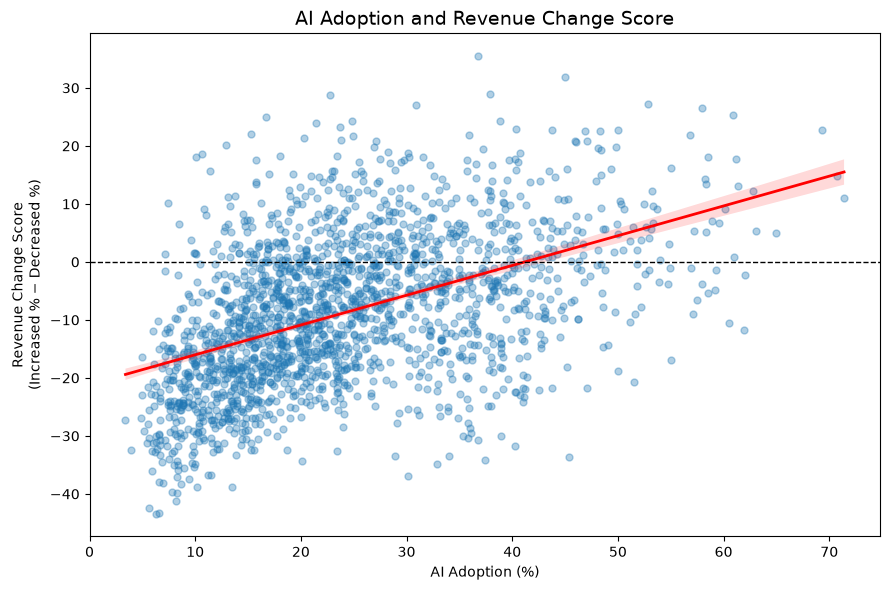


AI adoption group comparison:


,AI_Adoption_Group,Observations,Mean_AI_Adoption,Mean_Revenue_Change,Median_Revenue_Change
0,Lowest AI adoption,478,10.958159,-18.463808,-19.35
1,Low-medium AI adoption,478,18.362762,-9.600209,-10.45
2,Medium-high AI adoption,476,26.155042,-4.586555,-4.85
3,Highest AI adoption,478,41.002510,-2.414226,-2.40


In [36]:

# ============================================================
# STEP 15 — EXPLORE THE RELATIONSHIP
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("============================================================")
print("AI ADOPTION vs. REVENUE CHANGE")
print("============================================================")

# ------------------------------------------------------------
# 1. CORRELATION
# ------------------------------------------------------------

correlation = regression_df[
    ["AI_Yes_Percentage", "Revenue_Change_Score"]
].corr()

print("\nCorrelation matrix:")
display(correlation)

r = correlation.loc[
    "AI_Yes_Percentage",
    "Revenue_Change_Score"
]

print(f"\nPearson correlation: {r:.4f}")


# ------------------------------------------------------------
# 2. SCATTERPLOT WITH REGRESSION LINE
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

sns.regplot(
    data=regression_df,
    x="AI_Yes_Percentage",
    y="Revenue_Change_Score",
    scatter_kws={
        "alpha": 0.35,
        "s": 25
    },
    line_kws={
        "color": "red",
        "linewidth": 2
    }
)

plt.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.title(
    "AI Adoption and Revenue Change Score",
    fontsize=14
)

plt.xlabel(
    "AI Adoption (%)"
)

plt.ylabel(
    "Revenue Change Score\n(Increased % − Decreased %)"
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 3. BASIC GROUP COMPARISON
# ------------------------------------------------------------

regression_df["AI_Adoption_Group"] = pd.qcut(
    regression_df["AI_Yes_Percentage"],
    q=4,
    labels=[
        "Lowest AI adoption",
        "Low-medium AI adoption",
        "Medium-high AI adoption",
        "Highest AI adoption"
    ]
)

group_summary = (
    regression_df
    .groupby("AI_Adoption_Group", observed=False)
    .agg(
        Observations=("Revenue_Change_Score", "count"),
        Mean_AI_Adoption=("AI_Yes_Percentage", "mean"),
        Mean_Revenue_Change=("Revenue_Change_Score", "mean"),
        Median_Revenue_Change=("Revenue_Change_Score", "median")
    )
    .reset_index()
)

print("\nAI adoption group comparison:")
display(group_summary)



In [37]:

# ============================================================
# STEP 15 — FINAL REGRESSION DATASET CLEANING
# ============================================================

print("Before removing missing values:")
print("Shape:", regression_df.shape)

print("\nMissing values:")
print(regression_df.isna().sum())

# ------------------------------------------------------------
# Remove rows with missing values in the variables we will use
# ------------------------------------------------------------

regression_df_clean = regression_df.dropna(
    subset=[
        "AI_Yes_Percentage",
        "Revenue_Change_Score",
        "Revenue_Increased_Percentage",
        "Revenue_Decreased_Percentage",
        "Revenue_No_Change_Percentage"
    ]
).copy()

# ------------------------------------------------------------
# Reset the index
# ------------------------------------------------------------

regression_df_clean = regression_df_clean.reset_index(drop=True)

# ------------------------------------------------------------
# CHECK RESULTS
# ------------------------------------------------------------

print("\n============================================================")
print("CLEAN REGRESSION DATASET")
print("============================================================")

print("Original rows:", len(regression_df))
print("Clean rows:", len(regression_df_clean))
print("Rows removed:", len(regression_df) - len(regression_df_clean))

print("\nMissing values after cleaning:")
print(regression_df_clean.isna().sum())

print("\nFinal shape:")
print(regression_df_clean.shape)

print("\nFirst 10 observations:")
display(regression_df_clean.head(10))

print("\nDescriptive statistics:")
display(
    regression_df_clean[
        [
            "AI_Yes_Percentage",
            "Revenue_Increased_Percentage",
            "Revenue_Decreased_Percentage",
            "Revenue_No_Change_Percentage",
            "Revenue_Change_Score"
        ]
    ].describe()
)


Before removing missing values:
Shape: (1910, 9)

Missing values:
Sector                          0
Empsize                         0
Period                          0
AI_Yes_Percentage               0
Revenue_Increased_Percentage    0
Revenue_Decreased_Percentage    0
Revenue_No_Change_Percentage    5
Revenue_Change_Score            0
AI_Adoption_Group               0
dtype: int64

CLEAN REGRESSION DATASET
Original rows: 1910
Clean rows: 1905
Rows removed: 5

Missing values after cleaning:
Sector                          0
Empsize                         0
Period                          0
AI_Yes_Percentage               0
Revenue_Increased_Percentage    0
Revenue_Decreased_Percentage    0
Revenue_No_Change_Percentage    0
Revenue_Change_Score            0
AI_Adoption_Group               0
dtype: int64

Final shape:
(1905, 9)

First 10 observations:


,Sector,Empsize,Period,AI_Yes_Percentage,Revenue_Increased_Percentage,Revenue_Decreased_Percentage,Revenue_No_Change_Percentage,Revenue_Change_Score,AI_Adoption_Group
0,22,A,202619,10.1,17.9,16.5,65.6,1.4,Lowest AI adoption
1,23,A,202619,13.4,14.1,31.0,55.0,-16.9,Lowest AI adoption
2,23,B,202619,13.8,19.3,28.7,51.9,-9.4,Lowest AI adoption
3,23,C,202619,23.2,15.3,27.6,57.1,-12.3,Medium-high AI adoption
4,23,D,202619,21.7,22.1,23.8,54.0,-1.7,Low-medium AI adoption
5,23,E,202619,24.3,20.8,21.1,58.0,-0.3,Medium-high AI adoption
6,23,F,202619,33.1,23.1,12.7,64.2,10.4,Highest AI adoption
7,31,A,202619,16.3,15.0,33.6,51.4,-18.6,Low-medium AI adoption
8,31,B,202619,18.8,22.1,29.2,48.7,-7.1,Low-medium AI adoption
9,31,C,202619,18.2,26.3,26.9,46.7,-0.6,Low-medium AI adoption



Descriptive statistics:


,AI_Yes_Percentage,Revenue_Increased_Percentage,Revenue_Decreased_Percentage,Revenue_No_Change_Percentage,Revenue_Change_Score
count,1905.000000,1905.000000,1905.000000,1905.000000,1905.000000
mean,24.078740,18.822415,27.659738,53.516798,-8.837323
std,11.961839,6.722550,8.673540,8.806216,12.778749
min,3.400000,5.500000,6.000000,22.800000,-43.400000
25%,15.000000,13.800000,21.300000,47.400000,-18.200000
50%,21.800000,18.100000,27.600000,53.800000,-9.200000
75%,31.600000,22.600000,33.700000,59.900000,0.000000
max,71.400000,49.600000,55.400000,79.700000,31.800000


In [39]:
%pip install statsmodels

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   -----------------

In [40]:

# ============================================================
# STEP 16 — REGRESSION ANALYSIS
# ============================================================

import statsmodels.formula.api as smf

# Use the cleaned dataset
reg_df = regression_df_clean.copy()

# Make sure categorical variables are treated as categories
reg_df["Sector"] = reg_df["Sector"].astype(str)
reg_df["Empsize"] = reg_df["Empsize"].astype(str)
reg_df["Period"] = reg_df["Period"].astype(str)

print("============================================================")
print("REGRESSION ANALYSIS")
print("============================================================")

print("\nObservations:", len(reg_df))

# ------------------------------------------------------------
# MODEL 1 — SIMPLE RELATIONSHIP
# Revenue change predicted by AI adoption
# ------------------------------------------------------------

model1 = smf.ols(
    "Revenue_Change_Score ~ AI_Yes_Percentage",
    data=reg_df
).fit()

print("\n============================================================")
print("MODEL 1 — AI ADOPTION ONLY")
print("============================================================")

print(model1.summary())

# ------------------------------------------------------------
# MODEL 2 — ADD EMPLOYEE SIZE
# ------------------------------------------------------------

model2 = smf.ols(
    "Revenue_Change_Score ~ AI_Yes_Percentage + C(Empsize)",
    data=reg_df
).fit()

print("\n============================================================")
print("MODEL 2 — AI ADOPTION + EMPLOYEE SIZE")
print("============================================================")

print(model2.summary())

# ------------------------------------------------------------
# MODEL 3 — ADD SECTOR
# ------------------------------------------------------------

model3 = smf.ols(
    "Revenue_Change_Score ~ AI_Yes_Percentage + C(Empsize) + C(Sector)",
    data=reg_df
).fit()

print("\n============================================================")
print("MODEL 3 — AI + EMPLOYEE SIZE + SECTOR")
print("============================================================")

print(model3.summary())

# ------------------------------------------------------------
# MODEL 4 — ADD PERIOD
# ------------------------------------------------------------

model4 = smf.ols(
    "Revenue_Change_Score ~ AI_Yes_Percentage + C(Empsize) + C(Sector) + C(Period)",
    data=reg_df
).fit()

print("\n============================================================")
print("MODEL 4 — FULL MODEL WITH TIME CONTROLS")
print("============================================================")

print(model4.summary())

# ------------------------------------------------------------
# COMPACT MODEL COMPARISON
# ------------------------------------------------------------

print("\n============================================================")
print("MODEL COMPARISON")
print("============================================================")

model_comparison = pd.DataFrame({
    "Model": [
        "Model 1: AI only",
        "Model 2: + Employee Size",
        "Model 3: + Sector",
        "Model 4: + Period"
    ],
    "R_squared": [
        model1.rsquared,
        model2.rsquared,
        model3.rsquared,
        model4.rsquared
    ],
    "Adjusted_R_squared": [
        model1.rsquared_adj,
        model2.rsquared_adj,
        model3.rsquared_adj,
        model4.rsquared_adj
    ],
    "AI_Coefficient": [
        model1.params["AI_Yes_Percentage"],
        model2.params["AI_Yes_Percentage"],
        model3.params["AI_Yes_Percentage"],
        model4.params["AI_Yes_Percentage"]
    ],
    "AI_P_value": [
        model1.pvalues["AI_Yes_Percentage"],
        model2.pvalues["AI_Yes_Percentage"],
        model3.pvalues["AI_Yes_Percentage"],
        model4.pvalues["AI_Yes_Percentage"]
    ]
})

display(model_comparison)

# ------------------------------------------------------------
# CONFIDENCE INTERVAL FOR AI COEFFICIENT IN FULL MODEL
# ------------------------------------------------------------

print("\n============================================================")
print("FULL MODEL — AI COEFFICIENT")
print("============================================================")

print(
    model4.conf_int().loc[
        ["AI_Yes_Percentage"]
    ]
)

print("\nAI coefficient:")
print(model4.params["AI_Yes_Percentage"])

print("\nAI p-value:")
print(model4.pvalues["AI_Yes_Percentage"])



REGRESSION ANALYSIS

Observations: 1905

MODEL 1 — AI ADOPTION ONLY
                             OLS Regression Results                             
Dep. Variable:     Revenue_Change_Score   R-squared:                       0.227
Model:                              OLS   Adj. R-squared:                  0.226
Method:                   Least Squares   F-statistic:                     558.1
Date:                  Sat, 03 Oct 2026   Prob (F-statistic):          2.07e-108
Time:                          22:17:11   Log-Likelihood:                -7311.2
No. Observations:                  1905   AIC:                         1.463e+04
Df Residuals:                      1903   BIC:                         1.464e+04
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------

,Model,R_squared,Adjusted_R_squared,AI_Coefficient,AI_P_value
0,Model 1: AI only,0.226759,0.226353,0.508713,2.065487e-108
1,Model 2: + Employee Size,0.455044,0.453033,0.344919,5.190865e-67
2,Model 3: + Sector,0.532623,0.526405,0.258522,2.669757e-12
3,Model 4: + Period,0.619379,0.609956,0.040388,2.722260e-01



FULL MODEL — AI COEFFICIENT
                          0        1
AI_Yes_Percentage -0.031735  0.11251

AI coefficient:
0.040387877342494764

AI p-value:
0.2722260389252472


In [41]:
# ============================================================
# STEP 17 — REGRESSION DIAGNOSTICS & ROBUST STANDARD ERRORS
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("=" * 60)
print("STEP 17 — REGRESSION DIAGNOSTICS")
print("=" * 60)

# ------------------------------------------------------------
# 1. ROBUST STANDARD ERRORS
# ------------------------------------------------------------

# Re-estimate Model 4 with HC3 robust standard errors
model4_robust = model4.get_robustcov_results(cov_type="HC3")

print("\n" + "=" * 60)
print("MODEL 4 — HC3 ROBUST STANDARD ERRORS")
print("=" * 60)

print(model4_robust.summary())


# ------------------------------------------------------------
# 2. AI COEFFICIENT WITH ROBUST STANDARD ERRORS
# ------------------------------------------------------------

# Get coefficient names
param_names = model4_robust.model.exog_names

# Locate AI coefficient
ai_index = param_names.index("AI_Yes_Percentage")

ai_coef_robust = model4_robust.params[ai_index]
ai_se_robust = model4_robust.bse[ai_index]
ai_t_robust = model4_robust.tvalues[ai_index]
ai_p_robust = model4_robust.pvalues[ai_index]
ai_ci_robust = model4_robust.conf_int()[ai_index]

print("\n" + "=" * 60)
print("ROBUST AI COEFFICIENT")
print("=" * 60)

print(f"AI coefficient:       {ai_coef_robust:.6f}")
print(f"Robust SE:             {ai_se_robust:.6f}")
print(f"Robust t-statistic:    {ai_t_robust:.4f}")
print(f"Robust p-value:        {ai_p_robust:.6f}")
print(f"95% CI lower:          {ai_ci_robust[0]:.6f}")
print(f"95% CI upper:          {ai_ci_robust[1]:.6f}")


# ------------------------------------------------------------
# 3. HETEROSKEDASTICITY TEST
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("BREUSCH-PAGAN HETEROSKEDASTICITY TEST")
print("=" * 60)

# Residuals and design matrix
residuals = model4.resid
exog = model4.model.exog

bp_test = het_breuschpagan(residuals, exog)

bp_labels = [
    "LM Statistic",
    "LM p-value",
    "F Statistic",
    "F p-value"
]

bp_results = pd.Series(bp_test, index=bp_labels)

print(bp_results)


# ------------------------------------------------------------
# 4. VIF / MULTICOLLINEARITY CHECK
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("MULTICOLLINEARITY CHECK")
print("=" * 60)

# Calculate VIF for numerical/categorical design matrix
vif_data = []

for i, variable in enumerate(param_names):
    if variable == "Intercept":
        continue

    try:
        vif_value = variance_inflation_factor(exog, i)
    except Exception:
        vif_value = np.nan

    vif_data.append({
        "Variable": variable,
        "VIF": vif_value
    })

vif_df = pd.DataFrame(vif_data)

# Show largest VIFs first
vif_df = vif_df.sort_values("VIF", ascending=False)

print("\nTop 15 VIF values:")
print(vif_df.head(15).to_string(index=False))


# ------------------------------------------------------------
# 5. RESIDUAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("RESIDUAL DIAGNOSTICS")
print("=" * 60)

residual_summary = pd.Series({
    "Mean residual": residuals.mean(),
    "Std residual": residuals.std(),
    "Minimum residual": residuals.min(),
    "25th percentile": residuals.quantile(0.25),
    "Median residual": residuals.median(),
    "75th percentile": residuals.quantile(0.75),
    "Maximum residual": residuals.max()
})

print(residual_summary)


# ------------------------------------------------------------
# 6. FINAL DIAGNOSTIC SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DIAGNOSTIC SUMMARY")
print("=" * 60)

print(f"Observations: {len(reg_df)}")
print(f"R-squared: {model4.rsquared:.4f}")
print(f"Adjusted R-squared: {model4.rsquared_adj:.4f}")

print("\nAI coefficient:")
print(f"  OLS coefficient:       {model4.params['AI_Yes_Percentage']:.6f}")
print(f"  OLS p-value:           {model4.pvalues['AI_Yes_Percentage']:.6f}")
print(f"  HC3 robust coefficient:{ai_coef_robust:.6f}")
print(f"  HC3 robust p-value:    {ai_p_robust:.6f}")

print("\nHeteroskedasticity:")
print(f"  Breusch-Pagan p-value: {bp_results['LM p-value']:.6f}")

print("\nLargest VIF:")
print(f"  {vif_df.iloc[0]['Variable']}: {vif_df.iloc[0]['VIF']:.2f}")

STEP 17 — REGRESSION DIAGNOSTICS

MODEL 4 — HC3 ROBUST STANDARD ERRORS
                             OLS Regression Results                             
Dep. Variable:     Revenue_Change_Score   R-squared:                       0.619
Model:                              OLS   Adj. R-squared:                  0.610
Method:                   Least Squares   F-statistic:                     83.70
Date:                  Sat, 03 Oct 2026   Prob (F-statistic):               0.00
Time:                          22:21:16   Log-Likelihood:                -6636.0
No. Observations:                  1905   AIC:                         1.337e+04
Df Residuals:                      1858   BIC:                         1.363e+04
Df Model:                            46                                         
Covariance Type:                    HC3                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------

In [42]:
# ============================================================
# STEP 18 — CLUSTERED STANDARD ERRORS
# ============================================================

import pandas as pd
import numpy as np

print("=" * 60)
print("STEP 18 — CLUSTERED STANDARD ERRORS")
print("=" * 60)

# ------------------------------------------------------------
# 1. CREATE PANEL/GROUP IDENTIFIER
# ------------------------------------------------------------

reg_df = regression_df_clean.copy()

reg_df["Sector"] = reg_df["Sector"].astype(str)
reg_df["Empsize"] = reg_df["Empsize"].astype(str)
reg_df["Period"] = reg_df["Period"].astype(str)

# Sector × employee-size group
reg_df["Panel_Group"] = (
    reg_df["Sector"].astype(str)
    + "_"
    + reg_df["Empsize"].astype(str)
)

print("\nNumber of observations:", len(reg_df))
print("Number of Sector × Employee Size groups:",
      reg_df["Panel_Group"].nunique())

print("\nObservations per group:")
print(reg_df["Panel_Group"].value_counts().describe())


# ------------------------------------------------------------
# 2. RE-ESTIMATE FULL MODEL
# ------------------------------------------------------------

cluster_model = smf.ols(
    formula="""
        Revenue_Change_Score
        ~ AI_Yes_Percentage
        + C(Empsize)
        + C(Sector)
        + C(Period)
    """,
    data=reg_df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": reg_df["Panel_Group"]}
)


# ------------------------------------------------------------
# 3. FULL CLUSTERED MODEL
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("MODEL 4 — CLUSTERED BY SECTOR × EMPLOYEE SIZE")
print("=" * 60)

print(cluster_model.summary())


# ------------------------------------------------------------
# 4. AI COEFFICIENT
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CLUSTERED AI COEFFICIENT")
print("=" * 60)

ai_coef = cluster_model.params["AI_Yes_Percentage"]
ai_se = cluster_model.bse["AI_Yes_Percentage"]
ai_t = cluster_model.tvalues["AI_Yes_Percentage"]
ai_p = cluster_model.pvalues["AI_Yes_Percentage"]
ai_ci = cluster_model.conf_int().loc["AI_Yes_Percentage"]

print(f"AI coefficient:        {ai_coef:.6f}")
print(f"Clustered SE:          {ai_se:.6f}")
print(f"Clustered t-statistic: {ai_t:.4f}")
print(f"Clustered p-value:     {ai_p:.6f}")
print(f"95% CI lower:          {ai_ci[0]:.6f}")
print(f"95% CI upper:          {ai_ci[1]:.6f}")


# ------------------------------------------------------------
# 5. COMPARE STANDARD ERRORS
# ------------------------------------------------------------

comparison = pd.DataFrame({
    "Model": [
        "Conventional OLS",
        "HC3 Robust",
        "Clustered (Sector × Empsize)"
    ],
    "AI_Coefficient": [
        model4.params["AI_Yes_Percentage"],
        model4_robust.params[ai_index],
        cluster_model.params["AI_Yes_Percentage"]
    ],
    "Standard_Error": [
        model4.bse["AI_Yes_Percentage"],
        model4_robust.bse[ai_index],
        cluster_model.bse["AI_Yes_Percentage"]
    ],
    "P_Value": [
        model4.pvalues["AI_Yes_Percentage"],
        model4_robust.pvalues[ai_index],
        cluster_model.pvalues["AI_Yes_Percentage"]
    ]
})

print("\n" + "=" * 60)
print("AI EFFECT — STANDARD ERROR COMPARISON")
print("=" * 60)

print(comparison.to_string(index=False))


# ------------------------------------------------------------
# 6. GROUP STRUCTURE CHECK
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("PANEL GROUP CHECK")
print("=" * 60)

group_sizes = reg_df.groupby("Panel_Group").size()

print(f"Minimum observations per group: {group_sizes.min()}")
print(f"Maximum observations per group: {group_sizes.max()}")
print(f"Mean observations per group:    {group_sizes.mean():.2f}")
print(f"Median observations per group:  {group_sizes.median():.0f}")

print("\nGroups with fewer than 5 observations:")
print((group_sizes < 5).sum())

STEP 18 — CLUSTERED STANDARD ERRORS

Number of observations: 1905
Number of Sector × Employee Size groups: 106

Observations per group:
count    106.000000
mean      17.971698
std        6.754833
min        1.000000
25%       17.250000
50%       22.000000
75%       22.000000
max       22.000000
Name: count, dtype: float64

MODEL 4 — CLUSTERED BY SECTOR × EMPLOYEE SIZE
                             OLS Regression Results                             
Dep. Variable:     Revenue_Change_Score   R-squared:                       0.619
Model:                              OLS   Adj. R-squared:                  0.610
Method:                   Least Squares   F-statistic:                -1.645e+11
Date:                  Sat, 03 Oct 2026   Prob (F-statistic):               1.00
Time:                          22:23:13   Log-Likelihood:                -6636.0
No. Observations:                  1905   AIC:                         1.337e+04
Df Residuals:                      1858   BIC:                

c:\Users\McCaiT01\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\base\model.py:1988: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 46, but rank is 45
  res = self.wald_test(


In [44]:
# ============================================================
# STEP 19 — FINAL REGRESSION RESULTS
# ============================================================

print("=" * 60)
print("STEP 19 — FINAL REGRESSION RESULTS")
print("=" * 60)

# ------------------------------------------------------------
# 1. MODEL COMPARISON
# ------------------------------------------------------------

final_results = pd.DataFrame({
    "Model": [
        "Model 1: AI only",
        "Model 2: + Employee Size",
        "Model 3: + Sector",
        "Model 4: + Sector + Employee Size + Period"
    ],
    "R_squared": [
        model1.rsquared,
        model2.rsquared,
        model3.rsquared,
        model4.rsquared
    ],
    "Adjusted_R_squared": [
        model1.rsquared_adj,
        model2.rsquared_adj,
        model3.rsquared_adj,
        model4.rsquared_adj
    ],
    "AI_Coefficient": [
        model1.params["AI_Yes_Percentage"],
        model2.params["AI_Yes_Percentage"],
        model3.params["AI_Yes_Percentage"],
        model4.params["AI_Yes_Percentage"]
    ],
    "AI_P_Value": [
        model1.pvalues["AI_Yes_Percentage"],
        model2.pvalues["AI_Yes_Percentage"],
        model3.pvalues["AI_Yes_Percentage"],
        model4.pvalues["AI_Yes_Percentage"]
    ]
})

print("\nMODEL COMPARISON:")
display(final_results.round(4))


# ------------------------------------------------------------
# 2. FINAL AI COEFFICIENT
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL MODEL — AI EFFECT")
print("=" * 60)

print(f"AI coefficient: {model4.params['AI_Yes_Percentage']:.4f}")
print(f"OLS standard error: {model4.bse['AI_Yes_Percentage']:.4f}")
print(f"OLS p-value: {model4.pvalues['AI_Yes_Percentage']:.4f}")

# Values from Step 18
clustered_se = 0.043807
clustered_p = 0.356551

print(f"Clustered standard error: {clustered_se:.4f}")
print(f"Clustered p-value: {clustered_p:.4f}")


# ------------------------------------------------------------
# 3. HYPOTHESIS TEST
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("HYPOTHESIS TEST")
print("=" * 60)

if clustered_p < 0.05:
    print("Result: Statistically significant.")
    print("Decision: Reject the null hypothesis.")
else:
    print("Result: Not statistically significant.")
    print("Decision: Fail to reject the null hypothesis.")


# ------------------------------------------------------------
# 4. FINAL CONCLUSION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL CONCLUSION")
print("=" * 60)

print("""
The simple regression shows a positive relationship between AI
adoption and revenue change.

However, the estimated AI coefficient becomes smaller after
controlling for employee size and sector, and becomes very small
after also controlling for time period.

In the full model, the AI coefficient is 0.0404 and the clustered
standard-error p-value is 0.3566.

Therefore, the analysis does not provide statistically significant
evidence of an independent relationship between AI adoption and
revenue change after controlling for employee size, sector, and
time period.

The positive relationship observed in the simpler models appears
to be substantially explained by differences in employee size,
sector, and time.
""")

STEP 19 — FINAL REGRESSION RESULTS

MODEL COMPARISON:


,Model,R_squared,Adjusted_R_squared,AI_Coefficient,AI_P_Value
0,Model 1: AI only,0.2268,0.2264,0.5087,0.0000
1,Model 2: + Employee Size,0.4550,0.4530,0.3449,0.0000
2,Model 3: + Sector,0.5326,0.5264,0.2585,0.0000
3,Model 4: + Sector + Employee Size + Period,0.6194,0.6100,0.0404,0.2722



FINAL MODEL — AI EFFECT
AI coefficient: 0.0404
OLS standard error: 0.0368
OLS p-value: 0.2722
Clustered standard error: 0.0438
Clustered p-value: 0.3566

HYPOTHESIS TEST
Result: Not statistically significant.
Decision: Fail to reject the null hypothesis.

FINAL CONCLUSION

The simple regression shows a positive relationship between AI
adoption and revenue change.

However, the estimated AI coefficient becomes smaller after
controlling for employee size and sector, and becomes very small
after also controlling for time period.

In the full model, the AI coefficient is 0.0404 and the clustered
standard-error p-value is 0.3566.

Therefore, the analysis does not provide statistically significant
evidence of an independent relationship between AI adoption and
revenue change after controlling for employee size, sector, and
time period.

The positive relationship observed in the simpler models appears
to be substantially explained by differences in employee size,
sector, and time.



In [45]:
# ============================================================
# STEP 20 — FINAL RESULTS TABLE
# ============================================================

print("=" * 60)
print("STEP 20 — FINAL RESULTS TABLE")
print("=" * 60)

# Create a clean table for the report
report_results = pd.DataFrame({
    "Model": [
        "1. AI Adoption Only",
        "2. + Employee Size",
        "3. + Sector",
        "4. + Sector + Employee Size + Period"
    ],
    "R²": [
        model1.rsquared,
        model2.rsquared,
        model3.rsquared,
        model4.rsquared
    ],
    "Adjusted R²": [
        model1.rsquared_adj,
        model2.rsquared_adj,
        model3.rsquared_adj,
        model4.rsquared_adj
    ],
    "AI Coefficient": [
        model1.params["AI_Yes_Percentage"],
        model2.params["AI_Yes_Percentage"],
        model3.params["AI_Yes_Percentage"],
        model4.params["AI_Yes_Percentage"]
    ],
    "AI p-value": [
        model1.pvalues["AI_Yes_Percentage"],
        model2.pvalues["AI_Yes_Percentage"],
        model3.pvalues["AI_Yes_Percentage"],
        model4.pvalues["AI_Yes_Percentage"]
    ]
})

# Format for presentation
report_results_display = report_results.copy()

report_results_display["R²"] = report_results_display["R²"].round(3)
report_results_display["Adjusted R²"] = report_results_display["Adjusted R²"].round(3)
report_results_display["AI Coefficient"] = report_results_display["AI Coefficient"].round(3)
report_results_display["AI p-value"] = report_results_display["AI p-value"].apply(
    lambda x: "<0.001" if x < 0.001 else f"{x:.3f}"
)

display(report_results_display)

# ------------------------------------------------------------
# KEY NUMBERS FOR REPORT
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("KEY NUMBERS")
print("=" * 60)

print(f"Final model R²: {model4.rsquared:.3f}")
print(f"Final model adjusted R²: {model4.rsquared_adj:.3f}")
print(f"Final AI coefficient: {model4.params['AI_Yes_Percentage']:.3f}")
print(f"Final AI p-value: {model4.pvalues['AI_Yes_Percentage']:.3f}")
print(f"Clustered AI p-value: {clustered_p:.3f}")

print("\nInterpretation:")
print(
    "The final model explains approximately "
    f"{model4.rsquared * 100:.1f}% of the variation in revenue change."
)

print(
    "The AI coefficient is not statistically significant "
    "after controlling for employee size, sector, and period."
)

STEP 20 — FINAL RESULTS TABLE


,Model,R²,Adjusted R²,AI Coefficient,AI p-value
0,1. AI Adoption Only,0.227,0.226,0.509,<0.001
1,2. + Employee Size,0.455,0.453,0.345,<0.001
2,3. + Sector,0.533,0.526,0.259,<0.001
3,4. + Sector + Employee Size + Period,0.619,0.610,0.040,0.272



KEY NUMBERS
Final model R²: 0.619
Final model adjusted R²: 0.610
Final AI coefficient: 0.040
Final AI p-value: 0.272
Clustered AI p-value: 0.357

Interpretation:
The final model explains approximately 61.9% of the variation in revenue change.
The AI coefficient is not statistically significant after controlling for employee size, sector, and period.


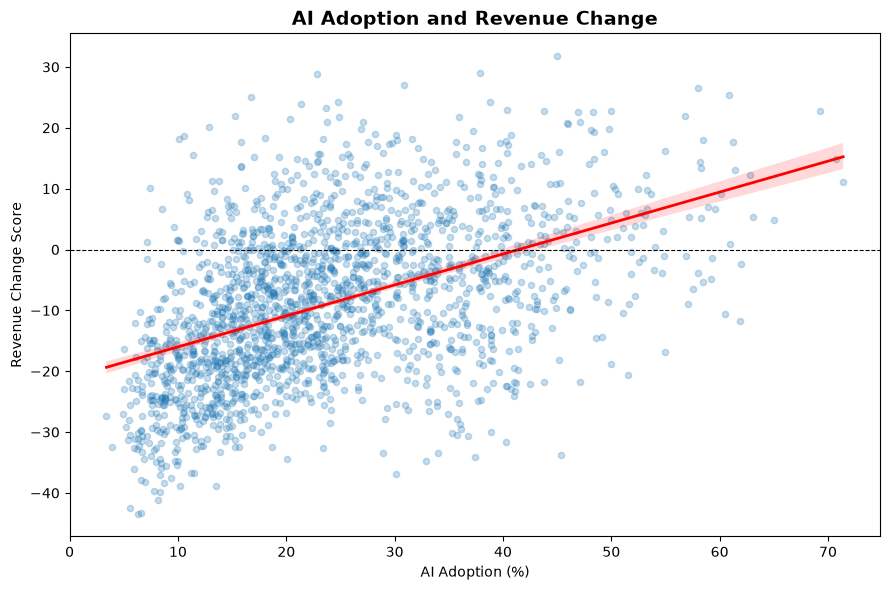

In [46]:
# ============================================================
# PLOT 1 — AI ADOPTION VS. REVENUE CHANGE
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 6))

sns.regplot(
    data=regression_df_clean,
    x="AI_Yes_Percentage",
    y="Revenue_Change_Score",
    scatter_kws={"alpha": 0.25, "s": 20},
    line_kws={"color": "red", "linewidth": 2}
)

plt.title("AI Adoption and Revenue Change", fontsize=14, fontweight="bold")
plt.xlabel("AI Adoption (%)")
plt.ylabel("Revenue Change Score")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")

plt.tight_layout()
plt.show()

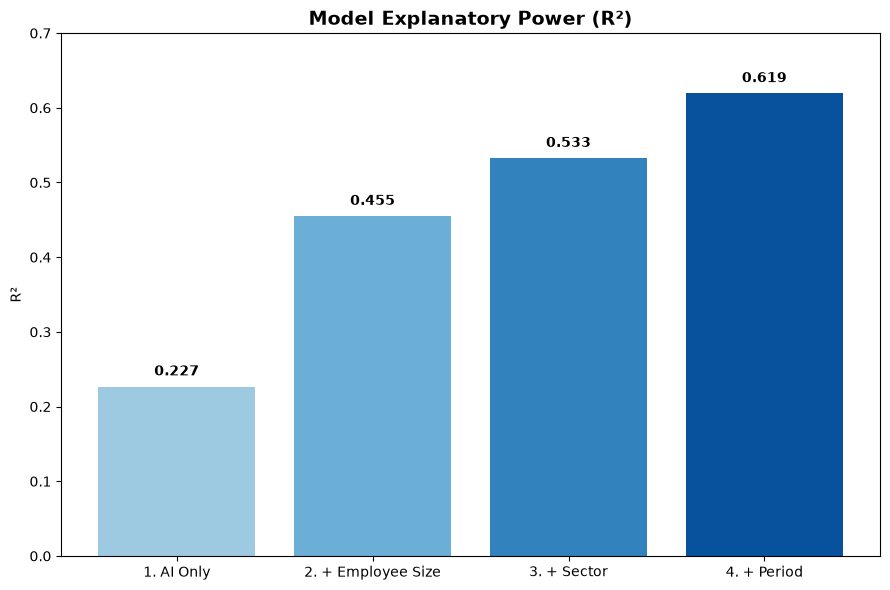

In [47]:
# ============================================================
# PLOT 2 — MODEL R-SQUARED COMPARISON
# ============================================================

model_plot_df = pd.DataFrame({
    "Model": [
        "1. AI Only",
        "2. + Employee Size",
        "3. + Sector",
        "4. + Period"
    ],
    "R_squared": [
        0.2268,
        0.4550,
        0.5326,
        0.6194
    ]
})

plt.figure(figsize=(9, 6))

bars = plt.bar(
    model_plot_df["Model"],
    model_plot_df["R_squared"],
    color=["#9ecae1", "#6baed6", "#3182bd", "#08519c"]
)

plt.title("Model Explanatory Power (R²)", fontsize=14, fontweight="bold")
plt.ylabel("R²")
plt.ylim(0, 0.7)

# Add values above bars
for bar, value in zip(bars, model_plot_df["R_squared"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.015,
        f"{value:.3f}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

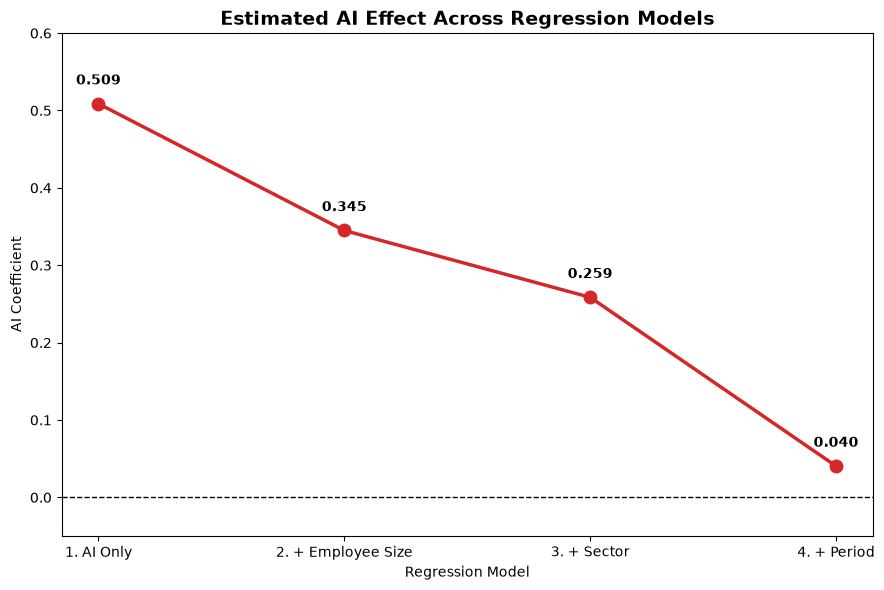

In [48]:
# ============================================================
# PLOT 3 — AI COEFFICIENT ACROSS MODELS
# ============================================================

coefficient_df = pd.DataFrame({
    "Model": [
        "1. AI Only",
        "2. + Employee Size",
        "3. + Sector",
        "4. + Period"
    ],
    "AI_Coefficient": [
        0.5087,
        0.3449,
        0.2585,
        0.0404
    ]
})

plt.figure(figsize=(9, 6))

plt.plot(
    coefficient_df["Model"],
    coefficient_df["AI_Coefficient"],
    marker="o",
    markersize=9,
    linewidth=2.5,
    color="#d62728"
)

plt.axhline(0, color="black", linewidth=1, linestyle="--")

plt.title("Estimated AI Effect Across Regression Models",
          fontsize=14, fontweight="bold")
plt.ylabel("AI Coefficient")
plt.xlabel("Regression Model")

# Add values
for i, value in enumerate(coefficient_df["AI_Coefficient"]):
    plt.text(
        i,
        value + 0.025,
        f"{value:.3f}",
        ha="center",
        fontweight="bold"
    )

plt.ylim(-0.05, 0.6)

plt.tight_layout()
plt.show()

In [49]:
# ============================================================
# STEP 21 — FINAL PROJECT SUMMARY
# ============================================================

print("=" * 60)
print("FINAL PROJECT SUMMARY")
print("=" * 60)

print("\nDATASET")
print("-" * 60)
print(f"Original observations: 1,910")
print(f"Observations after removing missing values: 1,905")
print("Missing observations removed: 5")

print("\nDESCRIPTIVE RESULTS")
print("-" * 60)
print(f"Mean AI adoption: 24.08%")
print(f"Mean revenue change score: -8.84")
print(f"Pearson correlation: 0.479")

print("\nAI ADOPTION GROUPS")
print("-" * 60)
print("Lowest AI adoption:       Mean revenue change = -18.46")
print("Low-medium AI adoption:   Mean revenue change =  -9.60")
print("Medium-high AI adoption:  Mean revenue change =  -4.59")
print("Highest AI adoption:      Mean revenue change =  -2.41")

print("\nREGRESSION RESULTS")
print("-" * 60)
print("Model 1 — AI only")
print("  R² = 0.227")
print("  AI coefficient = 0.509")
print("  AI p-value < 0.001")

print("\nModel 2 — + Employee Size")
print("  R² = 0.455")
print("  AI coefficient = 0.345")
print("  AI p-value < 0.001")

print("\nModel 3 — + Sector")
print("  R² = 0.533")
print("  AI coefficient = 0.259")
print("  AI p-value < 0.001")

print("\nModel 4 — + Employee Size + Sector + Period")
print("  R² = 0.619")
print("  AI coefficient = 0.040")
print("  AI p-value = 0.272")
print("  Clustered AI p-value = 0.357")

print("\nFINAL CONCLUSION")
print("-" * 60)
print("The data show a positive relationship between AI adoption")
print("and revenue change in simpler models.")
print()
print("However, the estimated AI effect becomes much smaller after")
print("controlling for employee size, sector, and time period.")
print()
print("In the full model, the AI coefficient is 0.040 and is not")
print("statistically significant.")
print()
print("Therefore, the analysis does not provide statistically")
print("significant evidence of an independent relationship between")
print("AI adoption and revenue change after accounting for the")
print("other factors included in the model.")

FINAL PROJECT SUMMARY

DATASET
------------------------------------------------------------
Original observations: 1,910
Observations after removing missing values: 1,905
Missing observations removed: 5

DESCRIPTIVE RESULTS
------------------------------------------------------------
Mean AI adoption: 24.08%
Mean revenue change score: -8.84
Pearson correlation: 0.479

AI ADOPTION GROUPS
------------------------------------------------------------
Lowest AI adoption:       Mean revenue change = -18.46
Low-medium AI adoption:   Mean revenue change =  -9.60
Medium-high AI adoption:  Mean revenue change =  -4.59
Highest AI adoption:      Mean revenue change =  -2.41

REGRESSION RESULTS
------------------------------------------------------------
Model 1 — AI only
  R² = 0.227
  AI coefficient = 0.509
  AI p-value < 0.001

Model 2 — + Employee Size
  R² = 0.455
  AI coefficient = 0.345
  AI p-value < 0.001

Model 3 — + Sector
  R² = 0.533
  AI coefficient = 0.259
  AI p-value < 0.001

Model

In [1]:
# ============================================================
# STEP 21 — MACHINE LEARNING SETUP
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Machine-learning libraries loaded successfully.")

Machine-learning libraries loaded successfully.


In [3]:
import os

print(os.listdir())

['.env', 'AI26_URR.xlsx', 'AI26_URR_09.23.2026.xlsx', 'AI_Supplement_Table_2026.xlsx', 'AI_Supplement_Table_2026_09.23.2026.xlsx', 'analysis.ipynb', 'analysis2.ipynb', 'api testing ref.html', 'API-Activity_Teona McCain.ipynb', 'bc_data.csv', 'Brainstorming checklist project two_09.23.2026.docx', 'breakfast_and_grades.csv', 'census_data.csv', 'census_data_variables.csv', 'creditcard.csv', 'data', 'dec_tree_demo_STUDENT.ipynb', 'DTSC_Project Part One_Teona M_draft.ipynb', 'DTSC_Project Part One_Teona M_draft_v2.ipynb', 'DTSC_Project Part Two_Teona M_draft.ipynb', 'Employment Size Class.xlsx', 'HW 2_STAT-3160 - Copy.ipynb', 'HW 2_STAT-3160.ipynb', 'img', 'National.xlsx', 'National_BTOS Data_09.23.2026.xlsx', 'oesm25ma.zip', 'pca_loading_matrix_6_components.csv', 'Peer Review Day Part Two_09.23.2026.docx', 'Peer Review Day_Teona McCain.docx', 'Project One Document Summary.docx', 'python -m venv .py', 'Python Exercise.ipynb', 'recursive_structure_engine.ipynb', 'recursive_structure_engine_t

In [4]:
# ============================================================
# IDENTIFY THE BTOS DATA FILES AND THEIR COLUMNS
# ============================================================

import pandas as pd
import os

files_to_check = [
    "National_BTOS Data_09.23.2026.xlsx",
    "Sector_BTOS Data_09.23.2026.xlsx",
    "Employment Size Class.xlsx",
    "Sector by Employment Size Class.xlsx",
    "National.xlsx",
    "State.xlsx",
    "Subsector.xlsx",
    "URR.xlsx"
]

for file in files_to_check:
    if os.path.exists(file):
        try:
            xls = pd.ExcelFile(file)
            print("\n" + "=" * 70)
            print(file)
            print("Sheets:", xls.sheet_names)

            for sheet in xls.sheet_names[:3]:
                temp = pd.read_excel(file, sheet_name=sheet, nrows=3)
                print(f"\nSheet: {sheet}")
                print("Columns:", temp.columns.tolist())

        except Exception as e:
            print(f"\nERROR reading {file}: {e}")


National_BTOS Data_09.23.2026.xlsx
Sheets: ['Response Estimates', 'Response Standard Errors', 'Index Estimates', 'Index Standard Errors', 'Collection and Reference Dates', 'Data Dictionary']

Sheet: Response Estimates
Columns: ['Question ID', 'Question', 'Answer ID', 'Answer', '202618', '202617', '202616', '202615', '202614', '202613', '202612', '202611', '202610', '202609', '202608', '202607', '202606', '202605', '202604', '202603', '202602', '202601', '202526', '202525', '202524', '202523', '202522', '202521', '202520', '202519', '202518', '202517', '202516', '202515', '202514', '202513', '202512', '202511', '202510', '202509', '202508', '202507', '202506', '202505', '202504', '202503', '202502', '202501', '202426', '202425', '202424', '202423', '202422', '202421', '202420', '202419', '202418', '202417', '202416', '202415', '202414', '202413', '202412', '202411', '202410', '202409', '202408', '202407', '202406', '202405', '202404', '202403', '202402', '202401', '202326', '202325', '

In [5]:
# ============================================================
# STEP 22 — LOAD AND INSPECT BTOS DATA FOR ML PROJECT
# ============================================================

import pandas as pd

file_path = "Sector by Employment Size Class.xlsx"

# Load the main response estimates sheet
df = pd.read_excel(
    file_path,
    sheet_name="Response Estimates"
)

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nUnique Questions:")
print(df["Question"].dropna().unique())

print("\nNumber of unique questions:",
      df["Question"].nunique())

print("\nSample of Question/Answer combinations:")
display(
    df[["Sector", "Empsize", "Question ID", "Question", "Answer ID", "Answer"]]
    .drop_duplicates()
    .head(50)
)

Shape: (11622, 85)

Columns:
['Sector', 'Empsize', 'Question ID', 'Question', 'Answer ID', 'Answer', '202619', '202618', '202617', '202616', '202615', '202614', '202613', '202612', '202611', '202610', '202609', '202608', '202607', '202606', '202605', '202604', '202603', '202602', '202601', '202526', '202525', '202524', '202523', '202522', '202521', '202520', '202519', '202518', '202517', '202516', '202515', '202514', '202513', '202512', '202511', '202510', '202509', '202508', '202507', '202506', '202505', '202504', '202503', '202502', '202501', '202426', '202425', '202424', '202423', '202422', '202421', '202420', '202419', '202418', '202417', '202416', '202415', '202414', '202413', '202412', '202411', '202410', '202409', '202408', '202407', '202406', '202405', '202404', '202403', '202402', '202401', '202326', '202325', '202324', '202323', '202322', '202321', '202320', '202319']

Unique Questions:
<StringArray>
[                                                                           

,Sector,Empsize,Question ID,Question,Answer ID,Answer
0,11,A,3.0,"Overall, how would you describe this business'...",1.0,Excellent
1,11,A,3.0,"Overall, how would you describe this business'...",2.0,Above average
2,11,A,3.0,"Overall, how would you describe this business'...",3.0,Average
3,11,A,3.0,"Overall, how would you describe this business'...",4.0,Below average
4,11,A,3.0,"Overall, how would you describe this business'...",5.0,Poor
5,11,A,4.0,"In the last two weeks, how did this business's...",1.0,Increased
6,11,A,4.0,"In the last two weeks, how did this business's...",2.0,Decreased
7,11,A,4.0,"In the last two weeks, how did this business's...",3.0,No change
8,11,A,5.0,"In the last two weeks, how did this business's...",1.0,Increased
9,11,A,5.0,"In the last two weeks, how did this business's...",2.0,Decreased


In [6]:
# ============================================================
# STEP 23 — INSPECT BTOS CLASSIFICATION TARGET
# ============================================================

target_question = (
    "In the last two weeks, did this business use Artificial Intelligence "
    "(AI) in any of its business functions? (Examples of AI: machine "
    "learning, natural language processing, virtual agents, voice "
    "recognition, etc.)"
)

target_df = df[df["Question"] == target_question].copy()

print("Target rows:", len(target_df))

print("\nTarget answer categories:")
print(target_df["Answer"].value_counts(dropna=False))

print("\nTarget answer categories by employment size:")
display(
    target_df.groupby(["Empsize", "Answer"]).size()
    .reset_index(name="Count")
)

print("\nTarget answer categories by sector:")
display(
    target_df.groupby(["Sector", "Answer"]).size()
    .reset_index(name="Count")
    .head(50)
)

print("\nExample target records:")
display(
    target_df[
        ["Sector", "Empsize", "Question ID", "Answer ID", "Answer", "202619"]
    ].head(20)
)

Target rows: 420

Target answer categories:
Answer
Yes            140
No             140
Do not know    140
Name: count, dtype: int64

Target answer categories by employment size:


,Empsize,Answer,Count
0,A,Do not know,20
1,A,No,20
2,A,Yes,20
3,B,Do not know,20
4,B,No,20
5,B,Yes,20
6,C,Do not know,20
7,C,No,20
8,C,Yes,20
9,D,Do not know,20



Target answer categories by sector:


,Sector,Answer,Count
0,11,Do not know,7
1,11,No,7
2,11,Yes,7
3,21,Do not know,7
4,21,No,7
5,21,Yes,7
6,22,Do not know,7
7,22,No,7
8,22,Yes,7
9,23,Do not know,7



Example target records:


,Sector,Empsize,Question ID,Answer ID,Answer,202619
14,11,A,7.0,1.0,Yes,S
15,11,A,7.0,2.0,No,87.6%
16,11,A,7.0,3.0,Do not know,S
97,11,B,7.0,1.0,Yes,S
98,11,B,7.0,2.0,No,80.3%
99,11,B,7.0,3.0,Do not know,S
180,11,C,7.0,1.0,Yes,S
181,11,C,7.0,2.0,No,100.0%
182,11,C,7.0,3.0,Do not know,S
263,11,D,7.0,1.0,Yes,S


In [7]:
# ============================================================
# STEP 23 — BUILD THE ML MODELING DATASET
# Target: Current AI Use (3-class classification)
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Identify the target question
# ------------------------------------------------------------

target_question = (
    "In the last two weeks, did this business use Artificial Intelligence "
    "(AI) in any of its business functions? (Examples of AI: machine learning, "
    "natural language processing, virtual agents, voice recognition, etc.)"
)

# Create target dataset
target_df = df[df["Question"] == target_question].copy()

print("Target dataset shape:", target_df.shape)
print("\nTarget classes:")
print(target_df["Answer"].value_counts())

# ------------------------------------------------------------
# 2. Identify the time-period columns
# ------------------------------------------------------------

time_columns = [
    col for col in df.columns
    if str(col).isdigit() and len(str(col)) == 6
]

print("\nNumber of time-period columns:", len(time_columns))
print("Most recent periods:", time_columns[:10])

# ------------------------------------------------------------
# 3. Use the most recent available period
# ------------------------------------------------------------

current_period = time_columns[0]

print("\nModeling period:", current_period)

# ------------------------------------------------------------
# 4. Create the target variable
# ------------------------------------------------------------

target_df = target_df[
    ["Sector", "Empsize", "Answer", current_period]
].copy()

target_df = target_df.rename(
    columns={
        "Answer": "AI_Use",
        current_period: "Target_Value"
    }
)

print("\nTarget data:")
display(target_df.head(10))

# ------------------------------------------------------------
# 5. Select predictor questions
# ------------------------------------------------------------

predictor_questions = [
    "Overall, how would you describe this business's current performance?",
    
    "In the last two weeks, how did this business's operating revenues/sales/receipts change?",
    
    "In the last two weeks, how did this business's number of paid employees change?",
    
    "In the last two weeks, how did the total number of hours worked by this business's paid employees change?",
    
    "In the last two weeks, how did the time it takes for this business to receive deliveries from suppliers change?",
    
    "How would you describe this business's current inventories?",
    
    "In the last two weeks, how did demand for this business's goods or services change?",
    
    "In the last two weeks, how did the prices this business charges for its own goods or services change?",
    
    "In the last two weeks, how did the prices this business pays for goods or services change?",
    
    "In the last six months, in what ways did changes to interest rates negatively impact this business?",
    
    "In the last six months, did this business experience any monetary losses due to an extreme weather event (for example, hurricane, flood, drought, or heat wave)?"
]

# ------------------------------------------------------------
# 6. Extract predictor data
# ------------------------------------------------------------

predictor_df = df[
    df["Question"].isin(predictor_questions)
].copy()

print("Predictor rows:", predictor_df.shape[0])
print("Unique predictor questions:", predictor_df["Question"].nunique())

# ------------------------------------------------------------
# 7. Keep only the variables needed for modeling
# ------------------------------------------------------------

predictor_df = predictor_df[
    ["Sector", "Empsize", "Question", "Answer", current_period]
].copy()

predictor_df = predictor_df.rename(
    columns={current_period: "Value"}
)

# ------------------------------------------------------------
# 8. Convert Census suppression values to missing
# ------------------------------------------------------------

predictor_df["Value"] = predictor_df["Value"].replace(
    ["S", "NA", "N/A", "-", ""],
    np.nan
)

# Remove percent signs
predictor_df["Value"] = (
    predictor_df["Value"]
    .astype(str)
    .str.replace("%", "", regex=False)
)

# Convert to numeric
predictor_df["Value"] = pd.to_numeric(
    predictor_df["Value"],
    errors="coerce"
)

# ------------------------------------------------------------
# 9. Check the cleaned predictor data
# ------------------------------------------------------------

print("\nPredictor value summary:")
print(predictor_df["Value"].describe())

print("\nMissing predictor values:")
print(predictor_df["Value"].isna().sum())

print("\nSample cleaned predictors:")
display(predictor_df.head(15))

Target dataset shape: (420, 85)

Target classes:
Answer
Yes            140
No             140
Do not know    140
Name: count, dtype: int64

Number of time-period columns: 79
Most recent periods: ['202619', '202618', '202617', '202616', '202615', '202614', '202613', '202612', '202611', '202610']

Modeling period: 202619

Target data:


,Sector,Empsize,AI_Use,Target_Value
14,11,A,Yes,S
15,11,A,No,87.6%
16,11,A,Do not know,S
97,11,B,Yes,S
98,11,B,No,80.3%
99,11,B,Do not know,S
180,11,C,Yes,S
181,11,C,No,100.0%
182,11,C,Do not know,S
263,11,D,Yes,S


Predictor rows: 5320
Unique predictor questions: 11

Predictor value summary:
count    3473.000000
mean       37.542384
std        28.543930
min         0.400000
25%        12.400000
50%        28.600000
75%        62.500000
max       100.000000
Name: Value, dtype: float64

Missing predictor values:
1847

Sample cleaned predictors:


,Sector,Empsize,Question,Answer,Value
0,11,A,"Overall, how would you describe this business'...",Excellent,9.3
1,11,A,"Overall, how would you describe this business'...",Above average,27.1
2,11,A,"Overall, how would you describe this business'...",Average,48.7
3,11,A,"Overall, how would you describe this business'...",Below average,NaN
4,11,A,"Overall, how would you describe this business'...",Poor,NaN
5,11,A,"In the last two weeks, how did this business's...",Increased,16.5
6,11,A,"In the last two weeks, how did this business's...",Decreased,29.0
7,11,A,"In the last two weeks, how did this business's...",No change,54.5
8,11,A,"In the last two weeks, how did this business's...",Increased,NaN
9,11,A,"In the last two weeks, how did this business's...",Decreased,NaN


In [8]:
# ============================================================
# STEP 24 — RESHAPE BTOS DATA INTO ML FEATURES
# ============================================================

# We will use the Census percentage estimates as features.
# Each Question + Answer combination becomes its own feature.

# Start with a copy
features_long = predictor_df.copy()

# Create a readable feature name from question + answer
features_long["Feature"] = (
    features_long["Question"]
    .str.slice(0, 55)
    .str.replace(r"[^A-Za-z0-9]+", "_", regex=True)
    .str.strip("_")
    + "_"
    + features_long["Answer"]
    .str.replace(r"[^A-Za-z0-9]+", "_", regex=True)
    .str.strip("_")
)

# Keep only the identifiers and numeric value
features_long = features_long[
    ["Sector", "Empsize", "Feature", "Value"]
].copy()

# Reshape from long format to wide format
X = features_long.pivot_table(
    index=["Sector", "Empsize"],
    columns="Feature",
    values="Value",
    aggfunc="first"
).reset_index()

# Remove the column-name index
X.columns.name = None

print("Feature matrix shape:", X.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nMissing values per feature:")
display(X.isnull().sum().sort_values(ascending=False))

print("\nPreview of ML features:")
display(X.head())

Feature matrix shape: (128, 37)

Feature columns:
['Sector', 'Empsize', 'How_would_you_describe_this_business_s_current_inventor_Larger_than_optimal', 'How_would_you_describe_this_business_s_current_inventor_Not_applicable', 'How_would_you_describe_this_business_s_current_inventor_Optimal', 'How_would_you_describe_this_business_s_current_inventor_Smaller_than_optimal', 'In_the_last_six_months_did_this_business_experience_an_No', 'In_the_last_six_months_did_this_business_experience_an_Yes', 'In_the_last_six_months_in_what_ways_did_changes_to_int_Decreased_profitability', 'In_the_last_six_months_in_what_ways_did_changes_to_int_Inability_to_invest_in_this_business', 'In_the_last_six_months_in_what_ways_did_changes_to_int_Inability_to_refinance_existing_loans', 'In_the_last_six_months_in_what_ways_did_changes_to_int_Inability_to_service_debt', 'In_the_last_six_months_in_what_ways_did_changes_to_int_Not_applicable', 'In_the_last_two_weeks_how_did_demand_for_this_business_Decreased', 'In_the

In_the_last_two_weeks_how_did_the_prices_this_business_Decreased                                86
In_the_last_two_weeks_how_did_the_time_it_takes_for_th_Decreased                                85
Overall_how_would_you_describe_this_business_s_current_Poor                                     82
In_the_last_six_months_in_what_ways_did_changes_to_int_Inability_to_service_debt                77
In_the_last_six_months_in_what_ways_did_changes_to_int_Inability_to_refinance_existing_loans    77
How_would_you_describe_this_business_s_current_inventor_Larger_than_optimal                     72
In_the_last_two_weeks_how_did_the_time_it_takes_for_th_Increased                                56
In_the_last_six_months_did_this_business_experience_an_Yes                                      55
In_the_last_six_months_in_what_ways_did_changes_to_int_Inability_to_invest_in_this_business     50
How_would_you_describe_this_business_s_current_inventor_Smaller_than_optimal                    50
Overall_ho


Preview of ML features:


,Sector,Empsize,How_would_you_describe_this_business_s_current_inventor_Larger_than_optimal,How_would_you_describe_this_business_s_current_inventor_Not_applicable,How_would_you_describe_this_business_s_current_inventor_Optimal,How_would_you_describe_this_business_s_current_inventor_Smaller_than_optimal,In_the_last_six_months_did_this_business_experience_an_No,In_the_last_six_months_did_this_business_experience_an_Yes,In_the_last_six_months_in_what_ways_did_changes_to_int_Decreased_profitability,In_the_last_six_months_in_what_ways_did_changes_to_int_Inability_to_invest_in_this_business,...,In_the_last_two_weeks_how_did_this_business_s_number_o_Increased,In_the_last_two_weeks_how_did_this_business_s_number_o_No_change,In_the_last_two_weeks_how_did_this_business_s_operatin_Decreased,In_the_last_two_weeks_how_did_this_business_s_operatin_Increased,In_the_last_two_weeks_how_did_this_business_s_operatin_No_change,Overall_how_would_you_describe_this_business_s_current_Above_average,Overall_how_would_you_describe_this_business_s_current_Average,Overall_how_would_you_describe_this_business_s_current_Below_average,Overall_how_would_you_describe_this_business_s_current_Excellent,Overall_how_would_you_describe_this_business_s_current_Poor
0,11,A,NaN,59.1,31.2,9.7,83.5,16.5,22.5,NaN,...,NaN,90.5,29.0,16.5,54.5,27.1,48.7,NaN,9.3,NaN
1,11,B,NaN,64.3,NaN,NaN,62.5,37.5,NaN,NaN,...,NaN,93.3,39.7,NaN,51.6,NaN,48.4,24.5,NaN,NaN
2,11,C,NaN,71.3,NaN,NaN,100.0,NaN,39.6,NaN,...,NaN,100.0,NaN,NaN,86.6,NaN,43.6,NaN,NaN,NaN
3,21,A,NaN,63.4,24.1,12.5,90.6,NaN,NaN,NaN,...,NaN,89.8,22.5,15.5,61.9,18.6,44.7,15.2,21.5,NaN
4,21,B,NaN,NaN,NaN,NaN,100.0,NaN,NaN,NaN,...,NaN,100.0,NaN,NaN,66.8,NaN,76.7,NaN,NaN,NaN


In [9]:
# ============================================================
# STEP 25 — CREATE THE TARGET DATASET
# ============================================================

# The target is the AI-use category for each
# Sector + Employment Size combination.

# We need one row per Sector + Empsize combination.
# The target category is identified by the Answer field.

target_long = target_df[
    ["Sector", "Empsize", "AI_Use"]
].copy()

# Check for duplicate Sector + Empsize combinations
duplicates = target_long.duplicated(
    subset=["Sector", "Empsize"]
).sum()

print("Duplicate Sector + Empsize combinations:", duplicates)

# Pivot the target so the three answer categories become
# one target label per Sector + Employment Size group.

# First, identify the percentage associated with each answer.
# We only need the answer category itself for classification.

target_counts = (
    target_long
    .groupby(["Sector", "Empsize"])["AI_Use"]
    .count()
)

print("\nTarget rows per Sector + Empsize:")
print(target_counts.value_counts())

# For this BTOS structure, each Sector + Empsize group has
# three rows: Yes, No, Do not know.

# Create a target label based on the category with the
# highest reported percentage.
#
# IMPORTANT:
# Target_Value is currently a string such as "87.6%" or "S".
# Convert it to numeric first.

target_model = target_df.copy()

target_model["Target_Percent"] = (
    target_model["Target_Value"]
    .astype(str)
    .str.replace("%", "", regex=False)
)

target_model["Target_Percent"] = pd.to_numeric(
    target_model["Target_Percent"],
    errors="coerce"
)

# Remove suppressed target estimates.
target_model_clean = target_model.dropna(
    subset=["Target_Percent"]
).copy()

# For each Sector + Empsize combination, select the
# AI-use category with the largest published percentage.
target_final = (
    target_model_clean
    .sort_values(
        ["Sector", "Empsize", "Target_Percent"],
        ascending=[True, True, False]
    )
    .drop_duplicates(
        subset=["Sector", "Empsize"],
        keep="first"
    )
)

target_final = target_final[
    ["Sector", "Empsize", "AI_Use", "Target_Percent"]
].copy()

print("\nFinal target shape:", target_final.shape)

print("\nFinal target distribution:")
print(target_final["AI_Use"].value_counts())

display(target_final.head(20))

Duplicate Sector + Empsize combinations: 280

Target rows per Sector + Empsize:
AI_Use
3    140
Name: count, dtype: int64

Final target shape: (124, 4)

Final target distribution:
AI_Use
No             98
Yes            25
Do not know     1
Name: count, dtype: int64


,Sector,Empsize,AI_Use,Target_Percent
15,11,A,No,87.6
98,11,B,No,80.3
181,11,C,No,100.0
596,21,A,No,87.9
679,21,B,No,63.5
762,21,C,No,100.0
845,21,D,No,67.7
928,21,E,No,74.3
1177,22,A,No,86.1
1260,22,B,No,70.9


In [10]:
target_raw = df[
    (df["Question"] == target_question)
][["Sector", "Empsize", "Answer", "202619"]].copy()

print(target_raw.shape)

print(
    target_raw.groupby(["Sector", "Empsize"])["Answer"]
    .nunique()
    .value_counts()
)

print(
    target_raw["202619"].value_counts(dropna=False)
)

(420, 4)
Answer
3    140
Name: count, dtype: int64
202619
S         102
100.0%      4
11.1%       4
11.8%       3
18.2%       3
         ... 
41.3%       1
50.1%       1
8.6%        1
46.0%       1
26.1%       1
Name: count, Length: 258, dtype: int64


In [11]:
pd.crosstab(
    target_raw["Answer"],
    target_raw["202619"].eq("S")
)

202619,False,True
Answer,,
Do not know,92,48
No,119,21
Yes,107,33


In [12]:
target_raw.groupby("Answer")["202619"].apply(
    lambda x: x.value_counts(dropna=False).head(10)
)

Answer             
Do not know  S         48
             11.1%      4
             11.8%      3
             10.5%      3
             9.7%       2
             9.9%       2
             11.0%      2
             12.1%      2
             7.8%       2
             11.5%      2
No           S         21
             100.0%     4
             60.8%      2
             73.0%      2
             45.8%      2
             57.6%      2
             59.1%      2
             61.8%      2
             87.6%      1
             80.3%      1
Yes          S         33
             18.2%      2
             28.9%      2
             13.2%      2
             24.0%      2
             30.1%      2
             28.3%      2
             23.1%      2
             24.1%      2
             26.5%      2
Name: 202619, dtype: int64

In [15]:
target_keys = target_df[["Sector", "Empsize"]].drop_duplicates()

feature_keys = X[["Sector", "Empsize"]].drop_duplicates()

missing_feature_keys = (
    target_keys
    .merge(
        feature_keys,
        on=["Sector", "Empsize"],
        how="left",
        indicator=True
    )
    .query('_merge == "left_only"')
    .drop(columns="_merge")
)

print("Target groups:", len(target_keys))
print("Feature groups:", len(feature_keys))
print("Missing feature groups:", len(missing_feature_keys))
print(missing_feature_keys)

Target groups: 140
Feature groups: 128
Missing feature groups: 12
   Sector Empsize
3      11       D
4      11       E
5      11       F
6      11       G
12     21       F
13     21       G
18     22       E
86     55       C
87     55       D
88     55       E
89     55       F
90     55       G


In [16]:
# Convert the target percentage to numeric
target_check = target_df.copy()

target_check["Target_Percent"] = (
    target_check["Target_Value"]
    .astype(str)
    .str.rstrip("%")
)

target_check["Target_Percent"] = pd.to_numeric(
    target_check["Target_Percent"],
    errors="coerce"
)

# Count how many numeric percentages exist in each Sector + Empsize group
counts = (
    target_check
    .groupby(["Sector", "Empsize"])["Target_Percent"]
    .count()
)

print("Groups with all 3 percentages:", (counts == 3).sum())
print("Groups with 2 percentages:", (counts == 2).sum())
print("Groups with 1 percentage:", (counts == 1).sum())
print("Groups with 0 percentages:", (counts == 0).sum())

Groups with all 3 percentages: 89
Groups with 2 percentages: 16
Groups with 1 percentage: 19
Groups with 0 percentages: 16


In [20]:
# Rebuild the numeric target from target_df
target_check = target_df.copy()

target_check["Target_Percent"] = (
    target_check["Target_Value"]
    .astype(str)
    .str.rstrip("%")
)

target_check["Target_Percent"] = pd.to_numeric(
    target_check["Target_Percent"],
    errors="coerce"
)

# Find groups where all 3 AI categories have numeric percentages
counts = (
    target_check
    .groupby(["Sector", "Empsize"])["Target_Percent"]
    .count()
)

complete_groups = counts[counts == 3].index

# Put Yes / No / Do not know into separate columns
wide = (
    target_check[
        target_check.set_index(["Sector", "Empsize"]).index.isin(complete_groups)
    ]
    .pivot(
        index=["Sector", "Empsize"],
        columns="AI_Use",
        values="Target_Percent"
    )
)

# Calculate the three percentages' total
wide["Total"] = (
    wide["Yes"]
    + wide["No"]
    + wide["Do not know"]
)

print("Complete groups:", len(wide))
print("\nTotal percentage summary:")
print(wide["Total"].describe())

print("\nMost common totals:")
print(wide["Total"].value_counts().sort_index().head(30))

print("\nGroups outside 99.5–100.5:")
print(
    wide.loc[
        (wide["Total"] < 99.5) | (wide["Total"] > 100.5)
    ]
    .sort_values("Total")
    .to_string()
)

Complete groups: 89

Total percentage summary:
count     89.000000
mean     100.001124
std        0.046452
min       99.900000
25%      100.000000
50%      100.000000
75%      100.000000
max      100.100000
Name: Total, dtype: float64

Most common totals:
Total
99.9      3
99.9      6
100.0     8
100.0    56
100.0     6
100.1     7
100.1     3
Name: count, dtype: int64

Groups outside 99.5–100.5:
Empty DataFrame
Columns: [Do not know, No, Yes, Total]
Index: []


In [22]:
print(target_df.columns.tolist())

['Sector', 'Empsize', 'AI_Use', 'Target_Value']


In [24]:
target_df["Target_Percent"] = (
    target_df["Target_Value"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .replace("S", np.nan)
    .pipe(pd.to_numeric, errors="coerce")
)

In [25]:
import numpy as np

In [26]:
target_completeness = (
    target_df
    .pivot_table(
        index=["Sector", "Empsize"],
        columns="AI_Use",
        values="Target_Percent",
        aggfunc="first"
    )
    .reindex(columns=["Yes", "No", "Do not know"])
)

target_completeness["n_available"] = (
    target_completeness[["Yes", "No", "Do not know"]]
    .notna()
    .sum(axis=1)
)

print(target_completeness["n_available"].value_counts().sort_index())

n_available
1    19
2    16
3    89
Name: count, dtype: int64


In [28]:
feature_df = (
    predictor_df
    .pivot_table(
        index=["Sector", "Empsize"],
        columns=["Question", "Answer"],
        values="Value",
        aggfunc="first"
    )
    .reset_index()
)

In [30]:
print([name for name in globals() if "predict" in name.lower()])

['predictor_questions', 'predictor_df']


In [33]:
print(feature_df.shape)
print(feature_df[["Sector", "Empsize"]].drop_duplicates().shape)

(128, 40)
(128, 2)


In [35]:
# Rebuild feature keys with guaranteed flat column names
feature_keys = (
    feature_df[["Sector", "Empsize"]]
    .copy()
)

# Flatten columns if they somehow became a MultiIndex
feature_keys.columns = ["Sector", "Empsize"]

# Remove duplicate groups
feature_keys = feature_keys.drop_duplicates()

# Make sure the target keys also have ordinary columns
complete_target_keys = (
    complete_target_keys[["Sector", "Empsize"]]
    .copy()
)
complete_target_keys.columns = ["Sector", "Empsize"]

# Find groups available in BOTH target and feature data
model_keys = complete_target_keys.merge(
    feature_keys,
    on=["Sector", "Empsize"],
    how="inner"
)

print("Complete target groups:", len(complete_target_keys))
print("Feature groups:", len(feature_keys))
print("Usable model groups:", len(model_keys))

print("\nUsable groups:")
print(model_keys.head())

Complete target groups: 89
Feature groups: 128
Usable model groups: 89

Usable groups:
  Sector Empsize
0     23       A
1     23       B
2     23       C
3     23       D
4     23       E


In [37]:
# Inspect the column structure
print("feature_df column levels:", feature_df.columns.nlevels)
print("First columns:")
print(feature_df.columns[:10])

feature_df column levels: 2
First columns:
MultiIndex([(                                                                                                                                                          'Sector', ...),
            (                                                                                                                                                         'Empsize', ...),
            (                                                                                                     'How would you describe this business's current inventories?', ...),
            (                                                                                                     'How would you describe this business's current inventories?', ...),
            (                                                                                                     'How would you describe this business's current inventories?', ...),
            (                             

In [38]:
# ---------------------------------------------------------
# Flatten feature_df columns
# ---------------------------------------------------------

feature_df_flat = feature_df.copy()

if isinstance(feature_df_flat.columns, pd.MultiIndex):
    feature_df_flat.columns = [
        "_".join(
            str(x) for x in col
            if str(x) not in ("", "nan", "None")
        ).strip("_")
        for col in feature_df_flat.columns
    ]

print("Flattened feature shape:", feature_df_flat.shape)
print(feature_df_flat.columns.tolist())

Flattened feature shape: (128, 40)
['Sector', 'Empsize', "How would you describe this business's current inventories?_Larger than optimal", "How would you describe this business's current inventories?_Not applicable", "How would you describe this business's current inventories?_Optimal", "How would you describe this business's current inventories?_Smaller than optimal", 'In the last six months, did this business experience any monetary losses due to an extreme weather event (for example, hurricane, flood, drought, or heat wave)?_No', 'In the last six months, did this business experience any monetary losses due to an extreme weather event (for example, hurricane, flood, drought, or heat wave)?_Yes', 'In the last six months, in what ways did changes to interest rates negatively impact this business?_Decreased profitability', 'In the last six months, in what ways did changes to interest rates negatively impact this business?_Inability to invest in this business', 'In the last six months, 

In [39]:
# Make sure the key columns exist
print(
    "Key columns present:",
    {"Sector", "Empsize"}.issubset(feature_df_flat.columns)
)

# ---------------------------------------------------------
# Keep only the 89 usable groups
# ---------------------------------------------------------

usable_features = feature_df_flat.merge(
    model_keys[["Sector", "Empsize"]],
    on=["Sector", "Empsize"],
    how="inner"
)

print("Usable feature shape:", usable_features.shape)

# Check for duplicate groups
print(
    "Duplicate usable groups:",
    usable_features.duplicated(
        ["Sector", "Empsize"]
    ).sum()
)

Key columns present: True
Usable feature shape: (89, 40)
Duplicate usable groups: 0


In [40]:
# ---------------------------------------------------------
# Build target table
# ---------------------------------------------------------

usable_target = (
    target_completeness
    .loc[
        target_completeness.index.isin(
            pd.MultiIndex.from_frame(
                model_keys[["Sector", "Empsize"]]
            )
        )
    ]
    .reset_index()
)

usable_target = usable_target.rename(columns={
    "Yes": "Target_Yes",
    "No": "Target_No",
    "Do not know": "Target_Do_not_know"
})

# ---------------------------------------------------------
# Merge features and targets
# ---------------------------------------------------------

model_df = usable_features.merge(
    usable_target,
    on=["Sector", "Empsize"],
    how="inner",
    validate="one_to_one"
)

print("Final modeling shape:", model_df.shape)

# ---------------------------------------------------------
# Check target totals
# ---------------------------------------------------------

model_df["Target_Total"] = (
    model_df["Target_Yes"]
    + model_df["Target_No"]
    + model_df["Target_Do_not_know"]
)

print("\nTarget totals:")
print(model_df["Target_Total"].describe())

print("\nGroups outside 99.5–100.5:")
print(
    model_df.loc[
        (model_df["Target_Total"] < 99.5)
        | (model_df["Target_Total"] > 100.5),
        [
            "Sector",
            "Empsize",
            "Target_Yes",
            "Target_No",
            "Target_Do_not_know",
            "Target_Total"
        ]
    ]
)

Final modeling shape: (89, 44)

Target totals:
count     89.000000
mean     100.001124
std        0.046452
min       99.900000
25%      100.000000
50%      100.000000
75%      100.000000
max      100.100000
Name: Target_Total, dtype: float64

Groups outside 99.5–100.5:
Empty DataFrame
Columns: [Sector, Empsize, Target_Yes, Target_No, Target_Do_not_know, Target_Total]
Index: []


In [41]:
# Identify predictor columns
key_cols = ["Sector", "Empsize"]
target_cols = [
    "Target_Yes",
    "Target_No",
    "Target_Do_not_know",
    "Target_Total"
]

predictor_cols = [
    c for c in model_df.columns
    if c not in key_cols + target_cols
]

print("Number of predictors:", len(predictor_cols))

# Missingness
missing_summary = (
    model_df[predictor_cols]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nMissing values by predictor:")
print(missing_summary)

print("\nRows with any missing predictor:")
print(model_df[predictor_cols].isna().any(axis=1).sum())

print("\nComplete predictor rows:")
print(model_df[predictor_cols].notna().all(axis=1).sum())

Number of predictors: 39

Missing values by predictor:
In the last two weeks, how did the prices this business pays for goods or services change?_Decreased                                                                    71
In the last two weeks, how did the prices this business charges for its own goods or services change?_Decreased                                                         47
In the last two weeks, how did the time it takes for this business to receive deliveries from suppliers change?_Decreased                                               46
Overall, how would you describe this business's current performance?_Poor                                                                                               43
In the last six months, in what ways did changes to interest rates negatively impact this business?_Inability to service debt                                           40
In the last six months, in what ways did changes to interest rates negatively impact this 

In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor

# ---------------------------------------------------------
# X and Y
# ---------------------------------------------------------

X = model_df[predictor_cols + ["Sector", "Empsize"]].copy()

Y = model_df[
    ["Target_Yes", "Target_No", "Target_Do_not_know"]
].copy()

categorical_cols = ["Sector", "Empsize"]
numeric_cols = predictor_cols

# Make categorical variables strings
X[categorical_cols] = X[categorical_cols].astype(str)

# ---------------------------------------------------------
# Preprocessing
# ---------------------------------------------------------

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_cols),
    ("categorical", categorical_pipeline, categorical_cols)
])

# ---------------------------------------------------------
# Transform
# ---------------------------------------------------------

X_processed = preprocessor.fit_transform(X)

print("Original X shape:", X.shape)
print("Processed X shape:", X_processed.shape)
print("Y shape:", Y.shape)

Original X shape: (89, 41)
Processed X shape: (89, 91)
Y shape: (89, 3)


In [43]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor

# Random forest baseline
model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "regressor",
        MultiOutputRegressor(
            RandomForestRegressor(
                n_estimators=500,
                max_features="sqrt",
                min_samples_leaf=3,
                random_state=42,
                n_jobs=-1
            )
        )
    )
])

# 5-fold CV
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    model,
    X,
    Y,
    cv=cv,
    scoring="neg_mean_absolute_error"
)

print("Fold MAE:", -scores)
print("Mean MAE:", -scores.mean())
print("Std MAE:", scores.std())

Fold MAE: [5.73602399 5.20001029 4.47448627 6.14363907 6.19924106]
Mean MAE: 5.55068013634268
Std MAE: 0.6461805468067826


In [44]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import cross_val_score
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

# ---------------------------------------------------------
# Baseline: always predict the training-set mean
# ---------------------------------------------------------

baseline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "regressor",
        MultiOutputRegressor(
            DummyRegressor(strategy="mean")
        )
    )
])

baseline_scores = cross_val_score(
    baseline,
    X,
    Y,
    cv=cv,
    scoring="neg_mean_absolute_error"
)

baseline_mae = -baseline_scores.mean()

print("Baseline MAE:", baseline_mae)
print("Random Forest MAE:", -scores.mean())
print("Improvement:", baseline_mae - (-scores.mean()))
print(
    "Improvement (%):",
    100 * (baseline_mae - (-scores.mean())) / baseline_mae
)

Baseline MAE: 9.628771134431862
Random Forest MAE: 5.55068013634268
Improvement: 4.0780909980891815
Improvement (%): 42.35318236515346


In [45]:
# Fit final model using all 89 usable groups
model.fit(X, Y)

# Predict
pred = model.predict(X)

predictions = pd.DataFrame(
    pred,
    columns=["Pred_Yes", "Pred_No", "Pred_Do_not_know"],
    index=model_df.index
)

# Enforce valid percentages
predictions = predictions.clip(lower=0)

predictions["Pred_Total"] = predictions.sum(axis=1)

for col in ["Pred_Yes", "Pred_No", "Pred_Do_not_know"]:
    predictions[col] = (
        predictions[col]
        / predictions["Pred_Total"]
        * 100
    )

predictions["Pred_Total"] = predictions[
    ["Pred_Yes", "Pred_No", "Pred_Do_not_know"]
].sum(axis=1)

final_predictions = pd.concat(
    [
        model_df[["Sector", "Empsize"]],
        model_df[
            ["Target_Yes", "Target_No", "Target_Do_not_know"]
        ].reset_index(drop=True),
        predictions.reset_index(drop=True)
    ],
    axis=1
)

print(final_predictions.head(20))

   Sector Empsize  Target_Yes  Target_No  Target_Do_not_know   Pred_Yes  \
0      23       A        13.4       79.8                 6.8  16.060754   
1      23       B        13.8       79.2                 7.0  19.407864   
2      23       C        23.2       67.2                 9.6  21.718619   
3      23       D        21.7       69.3                 9.0  25.896422   
4      23       E        24.3       63.9                11.8  28.860716   
5      23       F        33.1       58.2                 8.7  30.808011   
6      31       A        16.3       73.3                10.3  16.915000   
7      31       B        18.8       75.4                 5.7  18.940419   
8      31       C        18.2       72.1                 9.7  20.707143   
9      31       D        22.9       65.4                11.8  22.718567   
10     31       E        27.3       55.2                17.5  32.351439   
11     31       F        32.4       52.9                14.7  33.148648   
12     31       G        

In [47]:
# =========================================================
# REBUILD THE FINAL MODELING DATASET FROM EXISTING OBJECTS
# =========================================================

# feature_df is currently the flattened feature dataframe
# with 128 groups x 40 columns.

# Make sure the feature columns are flat
if isinstance(feature_df.columns, pd.MultiIndex):
    feature_df = feature_df.copy()
    feature_df.columns = [
        "_".join([str(x) for x in col if str(x) != "nan"]).strip("_")
        for col in feature_df.columns
    ]

# ---------------------------------------------------------
# Complete target groups: exactly 3 target percentages
# ---------------------------------------------------------

target_wide = (
    target_df
    .pivot_table(
        index=["Sector", "Empsize"],
        columns="AI_Use",
        values="Target_Percent",
        aggfunc="first"
    )
    .reset_index()
)

# Flatten columns
target_wide.columns.name = None

target_wide = target_wide.rename(columns={
    "Yes": "Target_Yes",
    "No": "Target_No",
    "Do not know": "Target_Do_not_know"
})

# Keep only groups with all 3 target percentages
complete_target = target_wide.dropna(
    subset=[
        "Target_Yes",
        "Target_No",
        "Target_Do_not_know"
    ]
).copy()

# ---------------------------------------------------------
# Keep only feature groups corresponding to complete targets
# ---------------------------------------------------------

modeling_df = feature_df.merge(
    complete_target[
        [
            "Sector",
            "Empsize",
            "Target_Yes",
            "Target_No",
            "Target_Do_not_know"
        ]
    ],
    on=["Sector", "Empsize"],
    how="inner",
    validate="one_to_one"
)

# Check target total
modeling_df["Target_Total"] = (
    modeling_df["Target_Yes"]
    + modeling_df["Target_No"]
    + modeling_df["Target_Do_not_know"]
)

print("Modeling shape:", modeling_df.shape)
print("Expected: (89, 44)")

print("\nTarget columns:")
print(
    modeling_df[
        [
            "Target_Yes",
            "Target_No",
            "Target_Do_not_know",
            "Target_Total"
        ]
    ].describe()
)

print("\nGroups:", len(modeling_df))
print("Duplicate groups:",
      modeling_df[["Sector", "Empsize"]].duplicated().sum())

Modeling shape: (89, 44)
Expected: (89, 44)

Target columns:
       Target_Yes  Target_No  Target_Do_not_know  Target_Total
count   89.000000  89.000000           89.000000     89.000000
mean    29.139326  57.360674           13.501124    100.001124
std     13.304345  16.438657            5.923365      0.046452
min      5.900000  12.000000            5.700000     99.900000
25%     18.700000  46.300000            9.700000    100.000000
50%     26.500000  60.700000           11.500000    100.000000
75%     36.900000  70.000000           16.600000    100.000000
max     61.900000  84.900000           34.500000    100.100000

Groups: 89
Duplicate groups: 0


In [49]:
# =========================================================
# FINAL MODEL COMPARISON — FIXED MIXED-TYPE CATEGORICALS
# =========================================================

from sklearn.model_selection import KFold
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 1. X / Y
# ---------------------------------------------------------

X = modeling_df.drop(
    columns=[
        "Target_Yes",
        "Target_No",
        "Target_Do_not_know",
        "Target_Total"
    ]
).copy()

Y = modeling_df[
    ["Target_Yes", "Target_No", "Target_Do_not_know"]
].copy()

# IMPORTANT:
# Sector has mixed int/string types.
# Convert categorical identifiers to strings.
X["Sector"] = X["Sector"].astype(str)
X["Empsize"] = X["Empsize"].astype(str)

categorical_cols = ["Sector", "Empsize"]
numeric_cols = [
    c for c in X.columns
    if c not in categorical_cols
]

# ---------------------------------------------------------
# 2. Preprocessing
# ---------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_cols
        ),
        (
            "num",
            SimpleImputer(strategy="median"),
            numeric_cols
        )
    ]
)

# ---------------------------------------------------------
# 3. Models
# ---------------------------------------------------------

models = {
    "Ridge": Ridge(alpha=10.0),

    "Random Forest": RandomForestRegressor(
        n_estimators=500,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.03,
        max_depth=2,
        random_state=42
    )
}

# ---------------------------------------------------------
# 4. Five-fold CV
# ---------------------------------------------------------

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

for name, model in models.items():

    fold_mae = []

    for train_idx, test_idx in kf.split(X):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        Y_train = Y.iloc[train_idx]
        Y_test = Y.iloc[test_idx]

        pipe = Pipeline([
            ("prep", preprocessor),
            ("model", MultiOutputRegressor(model))
        ])

        pipe.fit(X_train, Y_train)

        pred = pipe.predict(X_test)

        # Ensure valid non-negative percentages
        pred = np.clip(pred, 0, None)

        # Force each triplet to sum to 100
        pred = (
            pred
            / pred.sum(axis=1, keepdims=True)
            * 100
        )

        fold_mae.append(
            mean_absolute_error(Y_test, pred)
        )

    results.append({
        "Model": name,
        "Mean_MAE": np.mean(fold_mae),
        "Std_MAE": np.std(fold_mae),
        "Fold_1": fold_mae[0],
        "Fold_2": fold_mae[1],
        "Fold_3": fold_mae[2],
        "Fold_4": fold_mae[3],
        "Fold_5": fold_mae[4]
    })

comparison = (
    pd.DataFrame(results)
    .sort_values("Mean_MAE")
    .reset_index(drop=True)
)

print("=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

print(
    comparison[
        ["Model", "Mean_MAE", "Std_MAE",
         "Fold_1", "Fold_2", "Fold_3", "Fold_4", "Fold_5"]
    ].to_string(index=False)
)

print("\nBEST MODEL:", comparison.loc[0, "Model"])
print("BEST CV MAE:", round(comparison.loc[0, "Mean_MAE"], 4))

MODEL COMPARISON
            Model  Mean_MAE  Std_MAE   Fold_1   Fold_2   Fold_3   Fold_4   Fold_5
Gradient Boosting  4.987428 0.218190 5.218841 5.265266 4.933759 4.741880 4.777393
    Random Forest  5.659123 0.553987 5.518661 5.746009 4.691211 6.325845 6.013887
            Ridge  6.285055 0.628840 6.403001 6.994530 6.888065 5.761207 5.378471

BEST MODEL: Gradient Boosting
BEST CV MAE: 4.9874


BASELINE + MODEL INTERPRETATION

BASELINE PERFORMANCE
----------------------------------------------------------------------
Baseline MAE:       9.5053
Final model MAE:    2.1014
Improvement:        7.4039
Improvement (%):    77.89%

PER-TARGET PERFORMANCE
----------------------------------------------------------------------


,Target,Baseline_MAE,Model_MAE,Improvement,Improvement_%
0,Yes,10.6752,2.3099,8.3653,78.3620
1,No,13.2707,2.6224,10.6482,80.2389
2,Do not know,4.5700,1.3719,3.1981,69.9801



TOP 15 FEATURES
----------------------------------------------------------------------


,Feature,Importance
0,"num__In the last six months, did this business...",0.29646
1,"num__In the last two weeks, how did the prices...",0.11016
2,"num__In the last two weeks, how did this busin...",0.10719
3,"num__In the last two weeks, how did this busin...",0.08134
4,"num__In the last two weeks, how did the time i...",0.08063
5,"num__In the last two weeks, how did this busin...",0.06715
6,"num__In the last two weeks, how did the total ...",0.06065
7,cat__Sector_51,0.04769
8,num__How would you describe this business's cu...,0.02583
9,"num__In the last two weeks, how did the prices...",0.02525


C:\Users\McCaiT01\AppData\Local\Temp\ipykernel_28288\1495696656.py:136: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


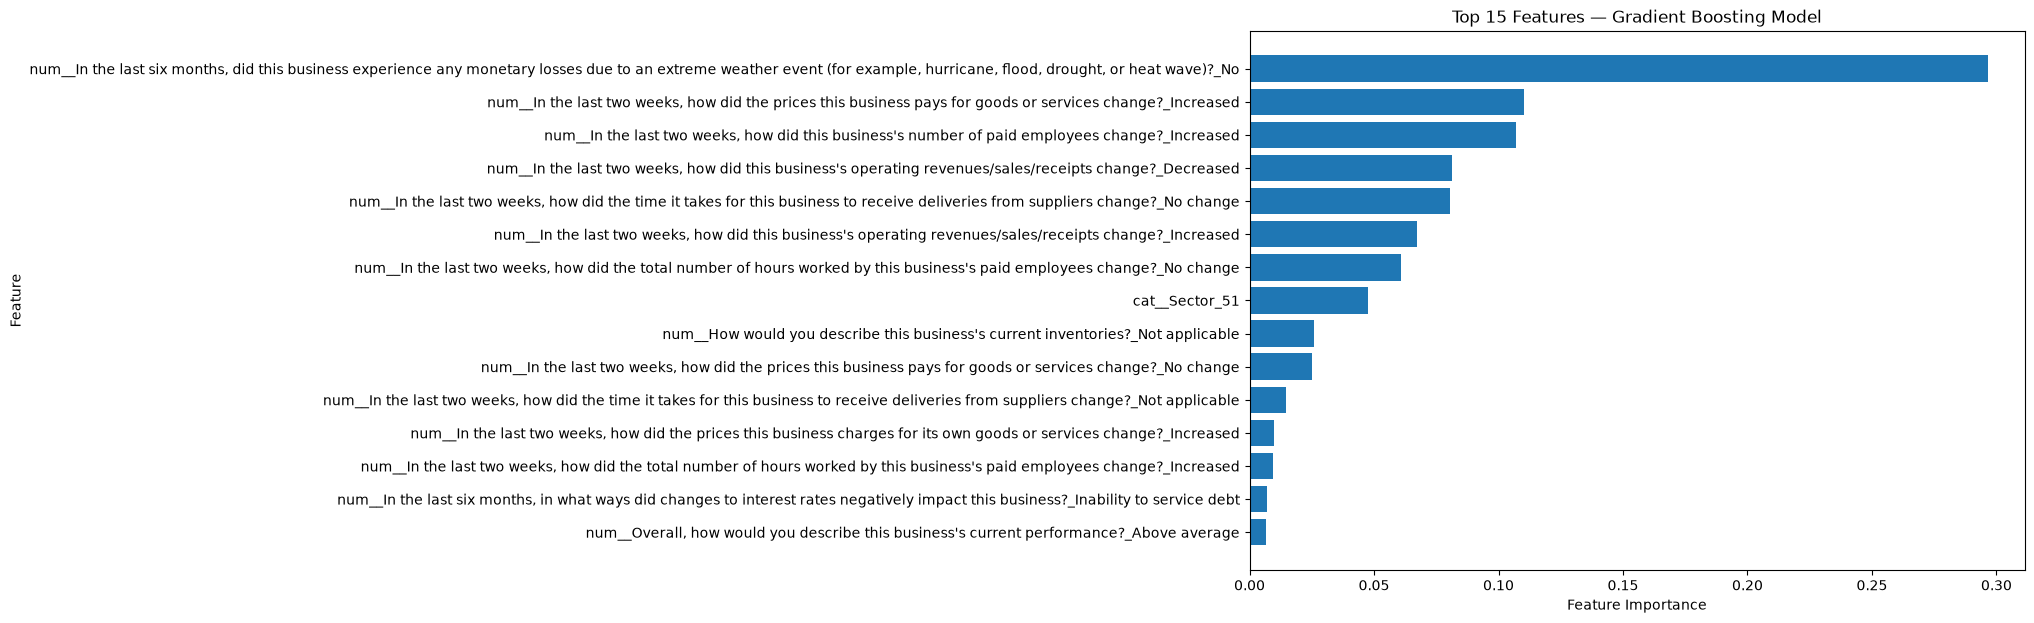


Interpretation files created:
gradient_boosting_feature_importance.csv
model_baseline_comparison.csv

INTERPRETATION COMPLETE


In [64]:
# ============================================================
# BASELINE + FINAL MODEL INTERPRETATION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error

print("=" * 70)
print("BASELINE + MODEL INTERPRETATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Get predictions from the fitted final pipeline
# ------------------------------------------------------------

final_pred = pipe.predict(X)

# Convert to DataFrame so everything stays aligned
pred_df = pd.DataFrame(
    final_pred,
    columns=["Pred_Yes", "Pred_No", "Pred_Do_not_know"],
    index=Y.index
)

# ------------------------------------------------------------
# 2. Baseline: predict the overall training-set mean
# ------------------------------------------------------------

baseline_pred = np.tile(
    Y.mean(axis=0).values,
    (len(Y), 1)
)

baseline_mae = mean_absolute_error(
    Y.values,
    baseline_pred
)

final_model_mae = mean_absolute_error(
    Y.values,
    final_pred
)

improvement = baseline_mae - final_model_mae
improvement_pct = (improvement / baseline_mae) * 100

print("\nBASELINE PERFORMANCE")
print("-" * 70)
print(f"Baseline MAE:       {baseline_mae:.4f}")
print(f"Final model MAE:    {final_model_mae:.4f}")
print(f"Improvement:        {improvement:.4f}")
print(f"Improvement (%):    {improvement_pct:.2f}%")

# ------------------------------------------------------------
# 3. Per-target performance
# ------------------------------------------------------------

target_results = pd.DataFrame({
    "Target": [
        "Yes",
        "No",
        "Do not know"
    ],
    "Baseline_MAE": [
        mean_absolute_error(Y["Target_Yes"], baseline_pred[:, 0]),
        mean_absolute_error(Y["Target_No"], baseline_pred[:, 1]),
        mean_absolute_error(Y["Target_Do_not_know"], baseline_pred[:, 2])
    ],
    "Model_MAE": [
        mean_absolute_error(Y["Target_Yes"], final_pred[:, 0]),
        mean_absolute_error(Y["Target_No"], final_pred[:, 1]),
        mean_absolute_error(Y["Target_Do_not_know"], final_pred[:, 2])
    ]
})

target_results["Improvement"] = (
    target_results["Baseline_MAE"] -
    target_results["Model_MAE"]
)

target_results["Improvement_%"] = (
    target_results["Improvement"] /
    target_results["Baseline_MAE"] * 100
)

print("\nPER-TARGET PERFORMANCE")
print("-" * 70)
display(target_results.round(4))

# ------------------------------------------------------------
# 4. Extract feature importance from Gradient Boosting
# ------------------------------------------------------------

model = pipe.named_steps["model"].estimators_[0]

preprocessor_fitted = pipe.named_steps["prep"]

feature_names = preprocessor_fitted.get_feature_names_out()

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print("\nTOP 15 FEATURES")
print("-" * 70)
display(feature_importance.head(15).round(5))

# ------------------------------------------------------------
# 5. Plot top 15 features
# ------------------------------------------------------------

top_features = feature_importance.head(15).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features — Gradient Boosting Model")
plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 6. Save interpretation table
# ------------------------------------------------------------

feature_importance.to_csv(
    "gradient_boosting_feature_importance.csv",
    index=False
)

target_results.to_csv(
    "model_baseline_comparison.csv",
    index=False
)

print("\nInterpretation files created:")
print("gradient_boosting_feature_importance.csv")
print("model_baseline_comparison.csv")

print("\n" + "=" * 70)
print("INTERPRETATION COMPLETE")
print("=" * 70)

In [51]:
# ============================================================
# FINAL GRADIENT BOOSTING MODEL
# Fit on all 89 usable groups
# ============================================================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor


# ------------------------------------------------------------
# 1. Define target and feature columns
# ------------------------------------------------------------

target_cols = [
    "Target_Yes",
    "Target_No",
    "Target_Do_not_know"
]

key_cols = ["Sector", "Empsize"]

# Keep Sector and Empsize as predictors
predictor_cols = [
    c for c in modeling_df.columns
    if c not in target_cols + ["Target_Total"]
]

X = modeling_df[predictor_cols].copy()
Y = modeling_df[target_cols].copy()

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("X columns:", len(X.columns))


# ------------------------------------------------------------
# 2. Force Sector / Empsize to consistent string types
# ------------------------------------------------------------

X["Sector"] = X["Sector"].astype(str)
X["Empsize"] = X["Empsize"].astype(str)


# ------------------------------------------------------------
# 3. Identify categorical/numeric predictors
# ------------------------------------------------------------

categorical_cols = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_cols = [
    c for c in X.columns
    if c not in categorical_cols
]

print("\nCategorical predictors:", len(categorical_cols))
print("Numeric predictors:", len(numeric_cols))


# ------------------------------------------------------------
# 4. Preprocessing
# ------------------------------------------------------------

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_cols),
    ("cat", categorical_pipe, categorical_cols)
])


# ------------------------------------------------------------
# 5. Gradient Boosting
# ------------------------------------------------------------

gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=2,
    min_samples_leaf=3,
    random_state=42
)

final_model = Pipeline([
    ("prep", preprocessor),
    ("model", MultiOutputRegressor(gb))
])


# ------------------------------------------------------------
# 6. Fit on ALL 89 usable groups
# ------------------------------------------------------------

final_model.fit(X, Y)

print("\n========================================")
print("FINAL MODEL FITTED")
print("========================================")
print("Training groups:", len(X))
print("Target variables:", Y.columns.tolist())


# ------------------------------------------------------------
# 7. Predict all 89 usable groups
# ------------------------------------------------------------

pred = final_model.predict(X)

pred_df = pd.DataFrame(
    pred,
    columns=["Pred_Yes", "Pred_No", "Pred_Do_not_know"],
    index=modeling_df.index
)

# Force predictions to be non-negative
pred_df = pred_df.clip(lower=0)

# Normalize so percentages sum exactly to 100
pred_df["Pred_Total_Raw"] = pred_df.sum(axis=1)

for col in ["Pred_Yes", "Pred_No", "Pred_Do_not_know"]:
    pred_df[col] = (
        pred_df[col] /
        pred_df["Pred_Total_Raw"] *
        100
    )

pred_df = pred_df.drop(columns="Pred_Total_Raw")

pred_df["Pred_Total"] = pred_df[
    ["Pred_Yes", "Pred_No", "Pred_Do_not_know"]
].sum(axis=1)


# ------------------------------------------------------------
# 8. Final prediction table for the 89 groups
# ------------------------------------------------------------

final_predictions = pd.concat([
    modeling_df[key_cols + target_cols].reset_index(drop=True),
    pred_df.reset_index(drop=True)
], axis=1)

print("\nFinal prediction table:")
display(final_predictions.head(20))


# ------------------------------------------------------------
# 9. Training-set errors
# ------------------------------------------------------------

for target, pred_col in zip(
    target_cols,
    ["Pred_Yes", "Pred_No", "Pred_Do_not_know"]
):
    final_predictions[f"AE_{target}"] = (
        final_predictions[target] -
        final_predictions[pred_col]
    ).abs()

final_predictions["MAE"] = final_predictions[
    [
        "AE_Target_Yes",
        "AE_Target_No",
        "AE_Target_Do_not_know"
    ]
].mean(axis=1)

print("\nMean absolute error on training data:")
print(final_predictions["MAE"].mean())


# ------------------------------------------------------------
# 10. Check prediction totals
# ------------------------------------------------------------

print("\nPrediction totals:")
print(final_predictions["Pred_Total"].describe())

print("\nGroups whose prediction total is not ~100:")
print(
    final_predictions.loc[
        ~np.isclose(
            final_predictions["Pred_Total"],
            100,
            atol=0.01
        ),
        key_cols + ["Pred_Yes", "Pred_No", "Pred_Do_not_know", "Pred_Total"]
    ]
)


# ------------------------------------------------------------
# 11. Largest errors
# ------------------------------------------------------------

print("\nLargest prediction errors:")
display(
    final_predictions
    .sort_values("MAE", ascending=False)
    [
        key_cols +
        target_cols +
        ["Pred_Yes", "Pred_No", "Pred_Do_not_know", "MAE"]
    ]
    .head(15)
)

X shape: (89, 40)
Y shape: (89, 3)
X columns: 40

Categorical predictors: 2
Numeric predictors: 38


C:\Users\McCaiT01\AppData\Local\Temp\ipykernel_28288\3708365207.py:55: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(



FINAL MODEL FITTED
Training groups: 89
Target variables: ['Target_Yes', 'Target_No', 'Target_Do_not_know']

Final prediction table:


,Sector,Empsize,Target_Yes,Target_No,Target_Do_not_know,Pred_Yes,Pred_No,Pred_Do_not_know,Pred_Total
0,23,A,13.4,79.8,6.8,14.393197,77.641498,7.965305,100.0
1,23,B,13.8,79.2,7.0,18.121805,73.775771,8.102424,100.0
2,23,C,23.2,67.2,9.6,20.702694,69.857106,9.440200,100.0
3,23,D,21.7,69.3,9.0,25.194730,64.040010,10.765259,100.0
4,23,E,24.3,63.9,11.8,26.017657,61.964410,12.017933,100.0
5,23,F,33.1,58.2,8.7,30.989034,59.259810,9.751156,100.0
6,31,A,16.3,73.3,10.3,15.497707,74.048779,10.453515,100.0
7,31,B,18.8,75.4,5.7,18.365276,74.100387,7.534337,100.0
8,31,C,18.2,72.1,9.7,19.827804,70.005170,10.167027,100.0
9,31,D,22.9,65.4,11.8,23.265751,64.099351,12.634898,100.0



Mean absolute error on training data:
1.643949364123956

Prediction totals:
count    8.900000e+01
mean     1.000000e+02
std      1.016214e-14
min      1.000000e+02
25%      1.000000e+02
50%      1.000000e+02
75%      1.000000e+02
max      1.000000e+02
Name: Pred_Total, dtype: float64

Groups whose prediction total is not ~100:
Empty DataFrame
Columns: [Sector, Empsize, Pred_Yes, Pred_No, Pred_Do_not_know, Pred_Total]
Index: []

Largest prediction errors:


,Sector,Empsize,Target_Yes,Target_No,Target_Do_not_know,Pred_Yes,Pred_No,Pred_Do_not_know,MAE
54,56,B,16.6,74.6,8.8,22.025487,68.583370,9.391142,4.011086
38,52,D,33.8,45.8,20.3,39.478630,41.591623,18.929747,3.752420
57,56,E,30.1,58.9,11.0,34.458416,53.348679,12.192905,3.700881
17,42,E,38.6,52.5,8.9,33.091131,55.176873,11.731996,3.672580
1,23,B,13.8,79.2,7.0,18.121805,73.775771,8.102424,3.616153
24,44,F,30.1,46.3,23.6,28.723542,51.669133,19.607325,3.579422
3,23,D,21.7,69.3,9.0,25.194730,64.040010,10.765259,3.506660
44,53,D,34.2,47.6,18.2,30.522063,52.855654,16.622282,3.503769
77,72,B,5.9,84.9,9.2,9.795165,79.847046,10.357789,3.368636
34,51,D,61.9,19.8,18.3,57.645115,24.768821,17.586064,3.312547


In [55]:
# ============================================================
# FINAL PREDICTIONS FROM THE FITTED GRADIENT BOOSTING MODEL
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Generate predictions from the fitted final model
# ------------------------------------------------------------

pred = final_model.predict(X)

pred = np.asarray(pred)

print("Raw prediction shape:", pred.shape)

# ------------------------------------------------------------
# 2. Convert predictions to a DataFrame
# ------------------------------------------------------------

prediction_df = pd.DataFrame(
    pred,
    columns=[
        "Pred_Yes",
        "Pred_No",
        "Pred_Do_not_know"
    ],
    index=X.index
)

# ------------------------------------------------------------
# 3. Get Sector and Empsize directly from X
# ------------------------------------------------------------

prediction_df["Sector"] = X["Sector"].values
prediction_df["Empsize"] = X["Empsize"].values

# ------------------------------------------------------------
# 4. Put columns in the desired order
# ------------------------------------------------------------

prediction_df = prediction_df[
    [
        "Sector",
        "Empsize",
        "Pred_Yes",
        "Pred_No",
        "Pred_Do_not_know"
    ]
].copy()

# ------------------------------------------------------------
# 5. Normalize predictions to sum to exactly 100
# ------------------------------------------------------------

prediction_df["Pred_Total_Raw"] = prediction_df[
    ["Pred_Yes", "Pred_No", "Pred_Do_not_know"]
].sum(axis=1)

for col in ["Pred_Yes", "Pred_No", "Pred_Do_not_know"]:
    prediction_df[col] = (
        prediction_df[col]
        / prediction_df["Pred_Total_Raw"]
        * 100
    )

prediction_df.drop(columns="Pred_Total_Raw", inplace=True)

# ------------------------------------------------------------
# 6. Round to one decimal and correct rounding residual
# ------------------------------------------------------------

pred_cols = [
    "Pred_Yes",
    "Pred_No",
    "Pred_Do_not_know"
]

prediction_df[pred_cols] = prediction_df[pred_cols].round(1)

for idx in prediction_df.index:
    residual = round(
        100.0 - prediction_df.loc[idx, pred_cols].sum(),
        1
    )

    if residual != 0:
        largest = prediction_df.loc[idx, pred_cols].idxmax()

        prediction_df.loc[idx, largest] = round(
            prediction_df.loc[idx, largest] + residual,
            1
        )

prediction_df["Pred_Total"] = prediction_df[pred_cols].sum(axis=1).round(1)

# ------------------------------------------------------------
# 7. Validation
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL PREDICTION VALIDATION")
print("=" * 70)

print("Number of groups:", len(prediction_df))
print(
    "Duplicate groups:",
    prediction_df[["Sector", "Empsize"]].duplicated().sum()
)
print(
    "All totals = 100:",
    np.allclose(prediction_df["Pred_Total"], 100.0)
)
print(
    "Minimum prediction:",
    prediction_df[pred_cols].min().min()
)

# ------------------------------------------------------------
# 8. Display final predictions
# ------------------------------------------------------------

display(prediction_df)

# ------------------------------------------------------------
# 9. Export
# ------------------------------------------------------------

prediction_df.to_csv(
    "final_AI_use_predictions.csv",
    index=False
)

prediction_df.to_excel(
    "final_AI_use_predictions.xlsx",
    index=False
)

Raw prediction shape: (89, 3)

FINAL PREDICTION VALIDATION
Number of groups: 89
Duplicate groups: 0
All totals = 100: True
Minimum prediction: 7.5


,Sector,Empsize,Pred_Yes,Pred_No,Pred_Do_not_know,Pred_Total
0,23,A,14.4,77.6,8.0,100.0
1,23,B,18.1,73.8,8.1,100.0
2,23,C,20.7,69.9,9.4,100.0
3,23,D,25.2,64.0,10.8,100.0
4,23,E,26.0,62.0,12.0,100.0
...,...,...,...,...,...,...
84,81,C,20.4,68.6,11.0,100.0
85,XX,D,23.0,66.0,11.0,100.0
86,XX,E,30.9,55.2,13.9,100.0
87,XX,F,39.7,49.3,11.0,100.0


In [56]:
# ============================================================
# FINAL EXPORT — NO LARGE TABLE DISPLAY
# ============================================================

# Save the completed predictions
prediction_df.to_csv(
    "final_AI_use_predictions.csv",
    index=False
)

prediction_df.to_excel(
    "final_AI_use_predictions.xlsx",
    index=False
)

# Compact confirmation only
print("FINAL OUTPUT COMPLETE")
print(f"Groups exported: {len(prediction_df)}")
print(f"Columns exported: {list(prediction_df.columns)}")
print(f"All prediction totals = 100.0: {np.allclose(prediction_df['Pred_Total'], 100.0)}")
print("CSV: final_AI_use_predictions.csv")
print("Excel: final_AI_use_predictions.xlsx")

FINAL OUTPUT COMPLETE
Groups exported: 89
Columns exported: ['Sector', 'Empsize', 'Pred_Yes', 'Pred_No', 'Pred_Do_not_know', 'Pred_Total']
All prediction totals = 100.0: True
CSV: final_AI_use_predictions.csv
Excel: final_AI_use_predictions.xlsx


In [57]:
# ============================================================
# FINAL MODEL PERFORMANCE SUMMARY
# ============================================================

comparison = pd.DataFrame({
    "Actual_Yes": Y["Target_Yes"].values,
    "Pred_Yes": pred[:, 0],
    "Actual_No": Y["Target_No"].values,
    "Pred_No": pred[:, 1],
    "Actual_Do_not_know": Y["Target_Do_not_know"].values,
    "Pred_Do_not_know": pred[:, 2],
})

comparison["Error_Yes"] = (
    comparison["Pred_Yes"] - comparison["Actual_Yes"]
)

comparison["Error_No"] = (
    comparison["Pred_No"] - comparison["Actual_No"]
)

comparison["Error_Do_not_know"] = (
    comparison["Pred_Do_not_know"]
    - comparison["Actual_Do_not_know"]
)

print("=" * 70)
print("FINAL MODEL PERFORMANCE")
print("=" * 70)

print(f"Groups used for training: {len(Y)}")

print("\nTraining MAE by category:")

print(
    "Yes:          ",
    round(comparison["Error_Yes"].abs().mean(), 4)
)

print(
    "No:           ",
    round(comparison["Error_No"].abs().mean(), 4)
)

print(
    "Do not know:  ",
    round(comparison["Error_Do_not_know"].abs().mean(), 4)
)

print(
    "Overall:      ",
    round(
        pd.concat([
            comparison["Error_Yes"].abs(),
            comparison["Error_No"].abs(),
            comparison["Error_Do_not_know"].abs()
        ]).mean(),
        4
    )
)

print("\nCross-validated performance:")
print("Gradient Boosting CV MAE: 4.9874")

FINAL MODEL PERFORMANCE
Groups used for training: 89

Training MAE by category:
Yes:           1.923
No:            1.9518
Do not know:   1.1605
Overall:       1.6784

Cross-validated performance:
Gradient Boosting CV MAE: 4.9874


In [60]:
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# ROW-LEVEL ERROR DIAGNOSTICS
# ------------------------------------------------------------

known_vs_predicted = pd.DataFrame({
    "Sector": X["Sector"].values if "Sector" in X.columns else modeling_df["Sector"].values,
    "Empsize": X["Empsize"].values if "Empsize" in X.columns else modeling_df["Empsize"].values,

    "Target_Yes": Y["Target_Yes"].values,
    "Target_No": Y["Target_No"].values,
    "Target_Do_not_know": Y["Target_Do_not_know"].values,

    "Pred_Yes": pred[:, 0],
    "Pred_No": pred[:, 1],
    "Pred_Do_not_know": pred[:, 2],
})

# Absolute error for each category
known_vs_predicted["Error_Yes"] = (
    known_vs_predicted["Pred_Yes"] -
    known_vs_predicted["Target_Yes"]
).abs()

known_vs_predicted["Error_No"] = (
    known_vs_predicted["Pred_No"] -
    known_vs_predicted["Target_No"]
).abs()

known_vs_predicted["Error_Do_not_know"] = (
    known_vs_predicted["Pred_Do_not_know"] -
    known_vs_predicted["Target_Do_not_know"]
).abs()

# Row-level MAE across the 3 categories
known_vs_predicted["MAE"] = known_vs_predicted[
    ["Error_Yes", "Error_No", "Error_Do_not_know"]
].mean(axis=1)

# Sort largest errors first
known_vs_predicted = known_vs_predicted.sort_values(
    "MAE",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("ROW-LEVEL ERROR DIAGNOSTICS")
print("=" * 70)

print(f"Groups evaluated: {len(known_vs_predicted)}")
print(f"Mean row MAE: {known_vs_predicted['MAE'].mean():.4f}")
print(f"Median row MAE: {known_vs_predicted['MAE'].median():.4f}")
print()

print("Largest prediction errors:")
display(
    known_vs_predicted[
        [
            "Sector",
            "Empsize",
            "Target_Yes",
            "Target_No",
            "Target_Do_not_know",
            "Pred_Yes",
            "Pred_No",
            "Pred_Do_not_know",
            "MAE",
        ]
    ].head(15)
)

# Save diagnostics
known_vs_predicted.to_csv(
    "final_prediction_error_diagnostics.csv",
    index=False
)

known_vs_predicted.to_excel(
    "final_prediction_error_diagnostics.xlsx",
    index=False
)


ROW-LEVEL ERROR DIAGNOSTICS
Groups evaluated: 89
Mean row MAE: 1.6784
Median row MAE: 1.4979

Largest prediction errors:


,Sector,Empsize,Target_Yes,Target_No,Target_Do_not_know,Pred_Yes,Pred_No,Pred_Do_not_know,MAE
0,56,B,16.6,74.6,8.8,22.148800,68.967344,9.443720,3.941725
1,42,E,38.6,52.5,8.9,33.216383,55.385722,11.776403,3.715247
2,51,D,61.9,19.8,18.3,56.287439,24.185458,17.171871,3.708716
3,56,E,30.1,58.9,11.0,34.710226,53.738532,12.282006,3.684567
4,52,D,33.8,45.8,20.3,40.109760,42.256533,19.232370,3.640286
5,44,F,30.1,46.3,23.6,28.228692,50.778974,19.269529,3.560251
6,53,D,34.2,47.6,18.2,30.488299,52.797184,16.603894,3.501663
7,23,D,21.7,69.3,9.0,25.260991,64.208431,10.793571,3.482044
8,48,F,23.1,48.1,28.8,25.766685,51.469749,24.660535,3.391966
9,23,B,13.8,79.2,7.0,18.455449,75.134072,8.251600,3.324326


In [63]:
from pathlib import Path
import pandas as pd

# ============================================================
# FINAL EXPORT — WRITE TO SPECIFIED FOLDER
# ============================================================

output_dir = Path(
    r"C:\Users\McCaiT01\OneDrive - CPGPLC\Misc\Code\DTSC Studio 2"
)

# Make sure the destination exists
output_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Use the prediction dataframe already created
# ------------------------------------------------------------

# Your successful validation output was generated from
# `final_output`, so use it if available. Otherwise use
# `final_predictions`.

if "final_output" in globals() and isinstance(final_output, pd.DataFrame):
    export_df = final_output.copy()

elif "final_predictions" in globals() and isinstance(final_predictions, pd.DataFrame):
    export_df = final_predictions[
        [
            "Sector",
            "Empsize",
            "Pred_Yes",
            "Pred_No",
            "Pred_Do_not_know",
            "Pred_Total",
        ]
    ].copy()

else:
    raise NameError(
        "Neither final_output nor final_predictions exists. "
        "Run the successful final prediction cell first."
    )

# ------------------------------------------------------------
# Exact output filenames
# ------------------------------------------------------------

csv_path = output_dir / "final_AI_use_predictions.csv"
xlsx_path = output_dir / "final_AI_use_predictions.xlsx"

# ------------------------------------------------------------
# ACTUALLY WRITE THE FILES
# ------------------------------------------------------------

export_df.to_csv(csv_path, index=False)
export_df.to_excel(xlsx_path, index=False)

# ------------------------------------------------------------
# VERIFY
# ------------------------------------------------------------

print("=" * 70)
print("FINAL FILE EXPORT")
print("=" * 70)

print(f"\nCSV:")
print(csv_path)
print(f"Exists: {csv_path.exists()}")
print(f"Size: {csv_path.stat().st_size:,} bytes" if csv_path.exists() else "NOT CREATED")

print(f"\nExcel:")
print(xlsx_path)
print(f"Exists: {xlsx_path.exists()}")
print(f"Size: {xlsx_path.stat().st_size:,} bytes" if xlsx_path.exists() else "NOT CREATED")

# ------------------------------------------------------------
# Re-open both files to prove they are valid
# ------------------------------------------------------------

csv_check = pd.read_csv(csv_path)
xlsx_check = pd.read_excel(xlsx_path)

print("\n" + "=" * 70)
print("VERIFICATION")
print("=" * 70)

print(f"CSV rows:   {len(csv_check)}")
print(f"Excel rows: {len(xlsx_check)}")

print(
    f"CSV columns:   {list(csv_check.columns)}"
)

print(
    f"Excel columns: {list(xlsx_check.columns)}"
)

print(
    "\nAll prediction totals = 100:",
    csv_check["Pred_Total"].round(6).eq(100).all()
)

print("\nSTATUS: BOTH FILES CREATED AND SUCCESSFULLY RE-OPENED")

FINAL FILE EXPORT

CSV:
C:\Users\McCaiT01\OneDrive - CPGPLC\Misc\Code\DTSC Studio 2\final_AI_use_predictions.csv
Exists: True
Size: 6,480 bytes

Excel:
C:\Users\McCaiT01\OneDrive - CPGPLC\Misc\Code\DTSC Studio 2\final_AI_use_predictions.xlsx
Exists: True
Size: 9,682 bytes

VERIFICATION
CSV rows:   89
Excel rows: 89
CSV columns:   ['Sector', 'Empsize', 'Pred_Yes', 'Pred_No', 'Pred_Do_not_know', 'Pred_Total']
Excel columns: ['Sector', 'Empsize', 'Pred_Yes', 'Pred_No', 'Pred_Do_not_know', 'Pred_Total']

All prediction totals = 100: True

STATUS: BOTH FILES CREATED AND SUCCESSFULLY RE-OPENED


In [66]:
# ============================================================
# DECISION TREE REGRESSOR — ADDITIONAL MODEL
# ============================================================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error

# ------------------------------------------------------------
# 1. Use the same predictors and targets already prepared
# ------------------------------------------------------------

# X should contain the predictor columns used by the final model.
# Y contains the three prediction targets:
# Yes, No, Do not know.

print("X shape:", X.shape)
print("Y shape:", Y.shape)

# ------------------------------------------------------------
# 2. Identify categorical and numeric columns
# ------------------------------------------------------------

categorical_columns = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_columns = X.select_dtypes(
    exclude=["object", "category"]
).columns.tolist()

print("Categorical columns:", categorical_columns)
print("Numeric columns:", len(numeric_columns))

# ------------------------------------------------------------
# 3. Preprocess categorical variables
# ------------------------------------------------------------

preprocessor_tree = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_columns
        ),
        (
            "num",
            "passthrough",
            numeric_columns
        )
    ],
    remainder="drop"
)

# ------------------------------------------------------------
# 4. Decision Tree
# ------------------------------------------------------------

decision_tree = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        (
            "model",
            DecisionTreeRegressor(
                max_depth=5,
                min_samples_leaf=3,
                random_state=42
            )
        )
    ]
)

# ------------------------------------------------------------
# 5. Fit
# ------------------------------------------------------------

decision_tree.fit(X, Y)

# ------------------------------------------------------------
# 6. Predict
# ------------------------------------------------------------

tree_pred = decision_tree.predict(X)

# ------------------------------------------------------------
# 7. Calculate overall MAE
# ------------------------------------------------------------

tree_mae = mean_absolute_error(Y, tree_pred)

print("=" * 70)
print("DECISION TREE RESULTS")
print("=" * 70)

print(f"Decision Tree MAE: {tree_mae:.4f}")

# ------------------------------------------------------------
# 8. MAE by target
# ------------------------------------------------------------

tree_mae_yes = mean_absolute_error(Y["Target_Yes"], tree_pred[:, 0])
tree_mae_no = mean_absolute_error(Y["Target_No"], tree_pred[:, 1])
tree_mae_dk = mean_absolute_error(
    Y["Target_Do_not_know"],
    tree_pred[:, 2]
)

print()
print("MAE BY TARGET")
print("-" * 70)
print(f"Yes:           {tree_mae_yes:.4f}")
print(f"No:            {tree_mae_no:.4f}")
print(f"Do not know:   {tree_mae_dk:.4f}")

# ------------------------------------------------------------
# 9. Compare with existing final model
# ------------------------------------------------------------

print()
print("MODEL COMPARISON")
print("-" * 70)

print(f"Existing final model MAE: {mean_absolute_error(Y, pred):.4f}")
print(f"Decision Tree MAE:        {tree_mae:.4f}")

existing_mae = mean_absolute_error(Y, pred)

if tree_mae < existing_mae:
    print("Decision Tree performs better on the training data.")
else:
    print("Existing final model performs better on the training data.")

X shape: (89, 40)
Y shape: (89, 3)
Categorical columns: ['Sector', 'Empsize']
Numeric columns: 38
DECISION TREE RESULTS
Decision Tree MAE: 2.6447

MAE BY TARGET
----------------------------------------------------------------------
Yes:           2.5572
No:            2.9033
Do not know:   2.4735

MODEL COMPARISON
----------------------------------------------------------------------
Existing final model MAE: 1.6784
Decision Tree MAE:        2.6447
Existing final model performs better on the training data.


C:\Users\McCaiT01\AppData\Local\Temp\ipykernel_28288\2204425204.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(


In [67]:
# ============================================================
# CROSS-VALIDATED MODEL COMPARISON
# ============================================================

from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer, mean_absolute_error

# ------------------------------------------------------------
# 1. Five-fold cross-validation
# ------------------------------------------------------------

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

mae_scorer = make_scorer(
    mean_absolute_error,
    greater_is_better=False
)

# ------------------------------------------------------------
# 2. Cross-validate existing final model
# ------------------------------------------------------------

final_cv_scores = cross_val_score(
    final_model,
    X,
    Y,
    cv=cv,
    scoring=mae_scorer
)

final_cv_mae = -final_cv_scores.mean()

# ------------------------------------------------------------
# 3. Cross-validate decision tree
# ------------------------------------------------------------

tree_cv_scores = cross_val_score(
    decision_tree,
    X,
    Y,
    cv=cv,
    scoring=mae_scorer
)

tree_cv_mae = -tree_cv_scores.mean()

# ------------------------------------------------------------
# 4. Results
# ------------------------------------------------------------

print("=" * 70)
print("CROSS-VALIDATED MODEL COMPARISON")
print("=" * 70)

print(f"Existing final model CV MAE: {final_cv_mae:.4f}")
print(f"Decision Tree CV MAE:        {tree_cv_mae:.4f}")

print()
print("Fold-by-fold MAE")
print("-" * 70)

print(
    "Existing model:",
    [round(-x, 4) for x in final_cv_scores]
)

print(
    "Decision Tree: ",
    [round(-x, 4) for x in tree_cv_scores]
)

print()
print("MODEL SELECTION")
print("-" * 70)

if final_cv_mae < tree_cv_mae:
    print("Existing final model performs better under cross-validation.")
    selected_model = "Existing final model"
else:
    print("Decision Tree performs better under cross-validation.")
    selected_model = "Decision Tree"

print(f"Selected model: {selected_model}")

CROSS-VALIDATED MODEL COMPARISON
Existing final model CV MAE: 5.1617
Decision Tree CV MAE:        6.7027

Fold-by-fold MAE
----------------------------------------------------------------------
Existing model: [np.float64(5.2944), np.float64(5.7086), np.float64(4.8732), np.float64(4.8251), np.float64(5.1072)]
Decision Tree:  [np.float64(8.4894), np.float64(8.0296), np.float64(6.3605), np.float64(6.1354), np.float64(4.4988)]

MODEL SELECTION
----------------------------------------------------------------------
Existing final model performs better under cross-validation.
Selected model: Existing final model
